# 타이어 불량 여부 판별을 위한 확장 EDA

## 목표
- 불량(NG)과 양품(Good)을 확실하게 구분할 수 있는 특성 발견
- 데이터 품질 및 분포 특성 파악
- 모델링을 위한 핵심 피처 선별

In [1]:
# 시스템 및 데이터 입력 제어
import os
import warnings
# 경고 메시지 무시
warnings.filterwarnings('ignore')
warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.simplefilter(action='ignore', category=UserWarning)
warnings.simplefilter(action='ignore', category=RuntimeWarning)

# 라이브러리
import pandas as pd
import numpy as np
import math
import scipy.stats as stats  # 왜도(Skewness)와 첨도(Kurtosis) 계산
from scipy.stats import ttest_ind, chi2_contingency, mannwhitneyu  # 통계적 검정

# 시각화
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# 머신러닝
from sklearn.ensemble import RandomForestClassifier, IsolationForest
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.cluster import KMeans
from sklearn.manifold import TSNE

# 한글 폰트 설정

# plt.rcParams['font.family'] = 'NanumGothic'
# plt.rcParams['axes.unicode_minus'] = False


import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# 폰트 리스트 새로 고침
fm.fontManager.ttflist

# 'NanumGothic'이 포함된 폰트 이름 출력
# 시스템에 따라 'NanumGothic', 'NanumGothicOTF', 'NanumGothic Coding' 등 이름이 다를 수 있습니다.
for font in fm.fontManager.ttflist:
    if 'NanumGothic' in font.name:
        print(font.name, font.fname)

        
# 그래프 스타일 설정
plt.style.use('default')
sns.set_palette("husl")

# 경고 메시지 숨기기
import warnings
warnings.filterwarnings('ignore')

NanumGothic /usr/share/fonts/truetype/nanum/NanumGothicBold.ttf
NanumGothic /usr/share/fonts/truetype/nanum/NanumGothicLight.ttf
NanumGothic /usr/share/fonts/truetype/nanum/NanumGothic.ttf
NanumGothic /usr/share/fonts/truetype/nanum/NanumGothicExtraBold.ttf
NanumGothic Eco /usr/share/fonts/truetype/nanum/NanumGothicEcoR.ttf
NanumGothic Eco /usr/share/fonts/truetype/nanum/NanumGothicEcoExtraBold.ttf
NanumGothicCoding /usr/share/fonts/truetype/nanum/NanumGothicCodingBold.ttf
NanumGothic Eco /usr/share/fonts/truetype/nanum/NanumGothicEcoBold.ttf
NanumGothicCoding /usr/share/fonts/truetype/nanum/NanumGothicCoding.ttf
NanumGothic Eco /usr/share/fonts/truetype/nanum/NanumGothicEco.ttf


In [17]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# 폰트 리스트 새로 고침
fm.fontManager.ttflist

# 'NanumGothic'이 포함된 폰트 이름 출력
# 시스템에 따라 'NanumGothic', 'NanumGothicOTF', 'NanumGothic Coding' 등 이름이 다를 수 있습니다.
for font in fm.fontManager.ttflist:
    if 'NanumGothic' in font.name:
        print(font.name, font.fname)

NanumGothic /usr/share/fonts/truetype/nanum/NanumGothic.ttf
NanumGothic /usr/share/fonts/truetype/nanum/NanumGothicBold.ttf
NanumGothic Eco /usr/share/fonts/truetype/nanum/NanumGothicEcoExtraBold.ttf
NanumGothic Eco /usr/share/fonts/truetype/nanum/NanumGothicEco.ttf
NanumGothicCoding /usr/share/fonts/truetype/nanum/NanumGothicCodingBold.ttf
NanumGothic Eco /usr/share/fonts/truetype/nanum/NanumGothicEcoR.ttf
NanumGothic Eco /usr/share/fonts/truetype/nanum/NanumGothicEcoBold.ttf
NanumGothic /usr/share/fonts/truetype/nanum/NanumGothicExtraBold.ttf
NanumGothicCoding /usr/share/fonts/truetype/nanum/NanumGothicCoding.ttf
NanumGothic /usr/share/fonts/truetype/nanum/NanumGothicLight.ttf


In [6]:
a = pd.read_csv('outputs/submission.csv')
print(len(a[a['decision']==True]))

200


In [4]:
# 데이터 로드
train = pd.read_csv('datasets/train.csv')
test = pd.read_csv('datasets/test.csv')

print(f"훈련 데이터: {train.shape}")
print(f"테스트 데이터: {test.shape}")
print(f"총 피처 수: {train.shape[1]}")

훈련 데이터: (720, 799)
테스트 데이터: (466, 799)
총 피처 수: 799


In [40]:
# object 형 변환하기

# Proc_Param6 -> P6_0, P6_1, P6_2 형식으로 되어있음
train['Proc_Param6'] = train['Proc_Param6'].str.split('_').str[-1].astype(int)
test['Proc_Param6'] = test['Proc_Param6'].str.split('_').str[-1].astype(int)
# Plant -> Plant_1, Plant_2, Plant_3... 형식으로 되어있음
train['Plant'] = train['Plant'].str.split('_').str[-1].astype(int)
test['Plant'] = test['Plant'].str.split('_').str[-1].astype(int)

## 1. 기본 데이터 탐색

기본 데이터 통계

훈련 데이터 크기: (720, 799)

타겟 분포:
Class
Good    613
NG      107
Name: count, dtype: int64

타겟 비율:
Class
Good    0.851389
NG      0.148611
Name: proportion, dtype: float64


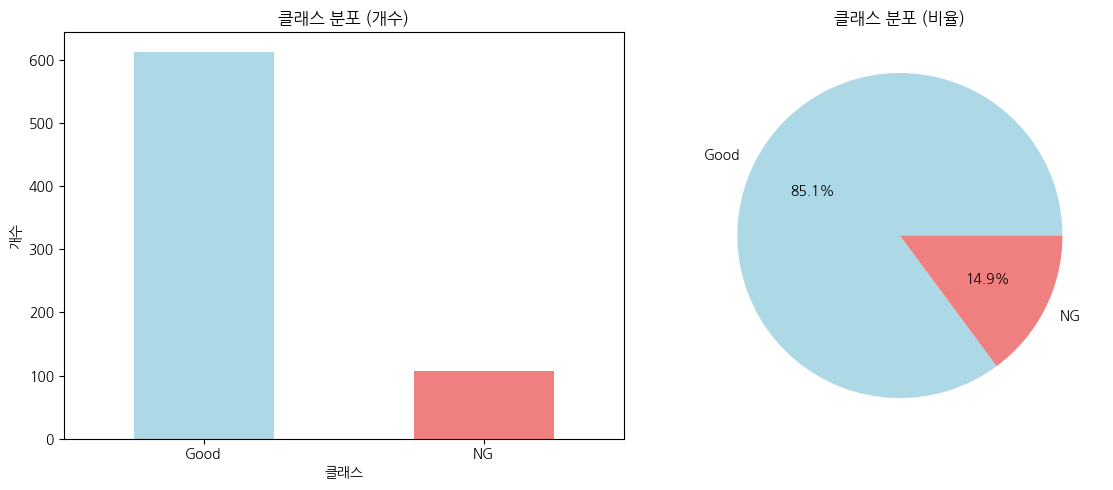


결측값 총 개수: 0


In [41]:
"""기본 통계"""
print("="*80)
print("기본 데이터 통계")
print("="*80)

print(f"\n훈련 데이터 크기: {train.shape}")
print(f"\n타겟 분포:")
print(train['Class'].value_counts())
print(f"\n타겟 비율:")
print(train['Class'].value_counts(normalize=True))

# 클래스 불균형 시각화
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# 막대 그래프
train['Class'].value_counts().plot(kind='bar', ax=ax1, color=['lightblue', 'lightcoral'])
ax1.set_title('클래스 분포 (개수)')
ax1.set_xlabel('클래스')
ax1.set_ylabel('개수')
ax1.tick_params(axis='x', rotation=0)

# 파이 차트
train['Class'].value_counts().plot(kind='pie', ax=ax2, autopct='%1.1f%%', 
                                   colors=['lightblue', 'lightcoral'])
ax2.set_title('클래스 분포 (비율)')
ax2.set_ylabel('')

plt.tight_layout()
plt.show()

# 결측값 확인
print(f"\n결측값 총 개수: {train.isnull().sum().sum()}")
if train.isnull().sum().sum() > 0:
    print("결측값이 있는 컬럼:")
    print(train.isnull().sum()[train.isnull().sum() > 0])

## 2. 설계 스펙 심화 분석


설계 스펙 상세 분석

--- 클래스별 설계 스펙 평균 ---
            Width                          Aspect                     \
             mean        std  min  max       mean        std min max   
Class                                                                  
Good   247.495922  28.401914  165  345  47.846656  11.768296  25  85   
NG     244.719626  24.163669  165  325  52.990654  10.942815  30  75   

            Inch                    
            mean       std min max  
Class                               
Good   18.887439  1.777323  13  24  
NG     18.467290  1.468652  14  23  

--- 설계 스펙 t-검정 결과 ---
Width     : t= 0.953, p-value=0.341110 ns
Aspect    : t=-4.214, p-value=0.000028 ***
Inch      : t= 2.311, p-value=0.021113 *


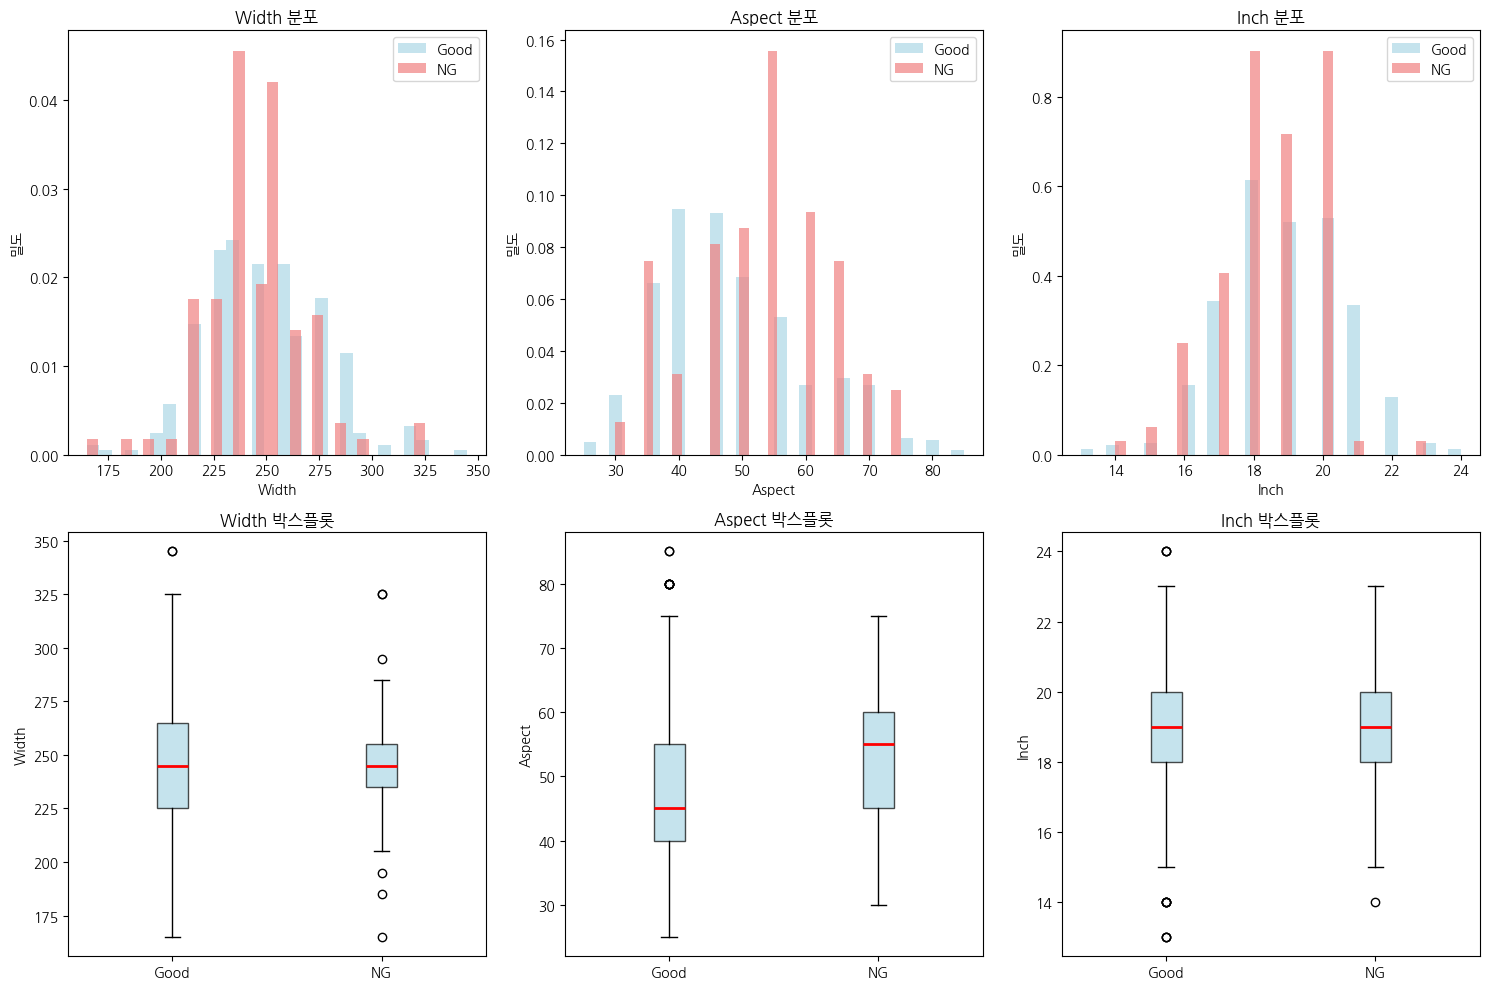

In [42]:
"""설계 스펙 상세 분석"""
print("\n" + "="*80)
print("설계 스펙 상세 분석")
print("="*80)

design_cols = ['Width', 'Aspect', 'Inch']

print("\n--- 클래스별 설계 스펙 평균 ---")
design_stats = train.groupby('Class')[design_cols].agg(['mean', 'std', 'min', 'max'])
print(design_stats)

# 통계적 유의성 검정
print("\n--- 설계 스펙 t-검정 결과 ---")
good_data = train[train['Class'] == 'Good']
ng_data = train[train['Class'] == 'NG']

for col in design_cols:
    stat, p_value = ttest_ind(good_data[col], ng_data[col])
    significance = "***" if p_value < 0.001 else "**" if p_value < 0.01 else "*" if p_value < 0.05 else "ns"
    print(f"{col:10s}: t={stat:6.3f}, p-value={p_value:.6f} {significance}")

# 설계 스펙 분포 시각화
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i, col in enumerate(design_cols):
    # 히스토그램
    good_values = good_data[col]
    ng_values = ng_data[col]
    
    axes[i].hist(good_values, bins=30, alpha=0.7, label='Good', color='lightblue', density=True)
    axes[i].hist(ng_values, bins=30, alpha=0.7, label='NG', color='lightcoral', density=True)
    axes[i].set_title(f'{col} 분포')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('밀도')
    axes[i].legend()
    
    # 박스플롯
    data_to_plot = [good_values, ng_values]
    axes[i+3].boxplot(data_to_plot, labels=['Good', 'NG'], patch_artist=True,
                      boxprops=dict(facecolor='lightblue', alpha=0.7),
                      medianprops=dict(color='red', linewidth=2))
    axes[i+3].set_title(f'{col} 박스플롯')
    axes[i+3].set_ylabel(col)

plt.tight_layout()
plt.show()


--- Mass_Pilot 분석 ---
Class       Good   NG  All
Mass_Pilot                
False        368   46  414
True         245   61  306
All          613  107  720

Mass_Pilot vs Class 카이제곱 검정: χ²=10.141, p-value=0.001450
Mass_Pilot과 Class 간에는 통계적으로 매우 유의미한 관계가 있습니다. 

--- Plant별 상세 분석 ---
         전체_수  NG_수  NG_비율(%)
Plant                        
Plant_9    15     5     33.33
Plant_1    27     7     25.93
Plant_0     4     1     25.00
Plant_2   231    51     22.08
Plant_8   100    15     15.00
Plant_6    27     4     14.81
Plant_4    63     8     12.70
Plant_7   241    16      6.64
Plant_5     4     0      0.00
Plant_3     8     0      0.00


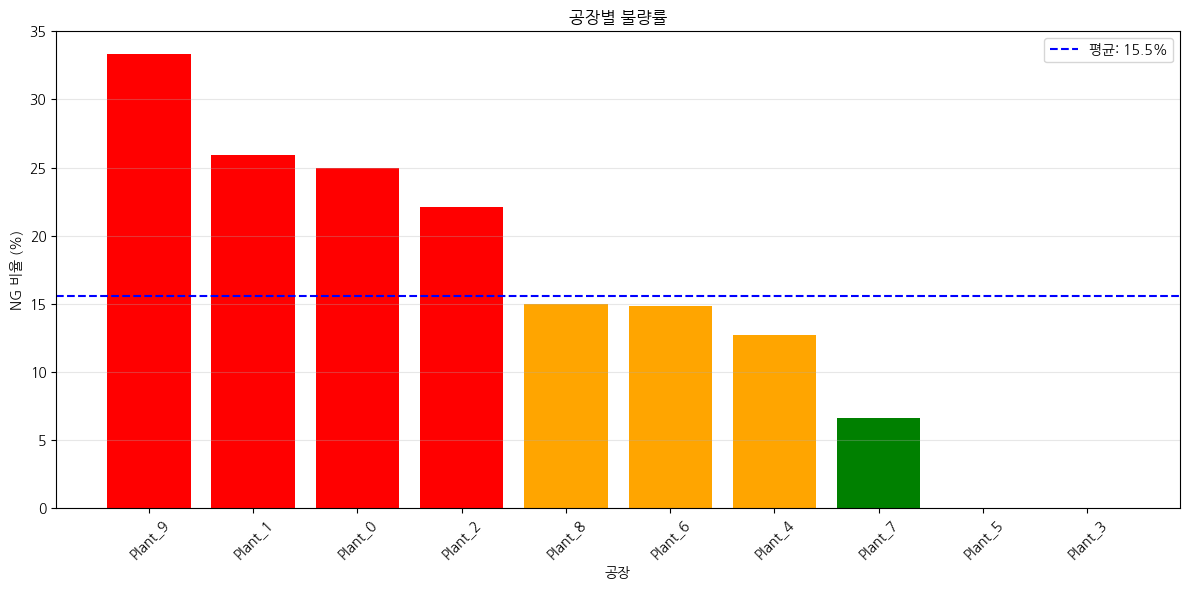

In [35]:
"""Mass_Pilot과 Plant 분석""" 
print("\n--- Mass_Pilot 분석 ---")
mass_pilot_table = pd.crosstab(train['Mass_Pilot'], train['Class'], margins=True)
print(mass_pilot_table)

# Mass_Pilot과 클래스의 연관성 검정
contingency = pd.crosstab(train['Mass_Pilot'], train['Class'])
chi2, p_value, dof, expected = chi2_contingency(contingency)
print(f"\nMass_Pilot vs Class 카이제곱 검정: χ²={chi2:.3f}, p-value={p_value:.6f}")
if p_value < 0.05:
    print(f"Mass_Pilot과 Class 간에는 통계적으로 매우 유의미한 관계가 있습니다. ")

print("\n--- Plant별 상세 분석 ---")
plant_analysis = train.groupby('Plant').agg({
    'Class': ['count', lambda x: (x == 'NG').sum(), lambda x: (x == 'NG').mean() * 100]
}).round(2)
plant_analysis.columns = ['전체_수', 'NG_수', 'NG_비율(%)']
plant_analysis = plant_analysis.sort_values('NG_비율(%)', ascending=False)
print(plant_analysis)

# Plant별 NG 비율 시각화
plt.figure(figsize=(12, 6))
plant_ng_rate = train.groupby('Plant')['Class'].apply(lambda x: (x == 'NG').mean() * 100).sort_values(ascending=False)
bars = plt.bar(range(len(plant_ng_rate)), plant_ng_rate.values, 
               color=['red' if x > 20 else 'orange' if x > 10 else 'green' for x in plant_ng_rate.values])
plt.xlabel('공장')
plt.ylabel('NG 비율 (%)')
plt.title('공장별 불량률')
plt.xticks(range(len(plant_ng_rate)), plant_ng_rate.index, rotation=45)
plt.axhline(y=plant_ng_rate.mean(), color='blue', linestyle='--', label=f'평균: {plant_ng_rate.mean():.1f}%')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## 3. 공정 파라미터 분석

In [49]:
"""공정 파라미터 심화 분석"""
print("\n" + "="*80)
print("공정 파라미터 분석")
print("="*80)

# 공정 파라미터 컬럼 찾기
proc_cols = [col for col in train.columns if col.startswith('Proc_Param')]
print(f"\n공정 파라미터 개수: {len(proc_cols)}")
print(f"공정 파라미터: {proc_cols}")

# 데이터 타입 확인 및 전처리
print("\n--- 공정 파라미터 데이터 타입 확인 ---")
proc_data_clean = train[proc_cols].copy()

# 각 컬럼의 데이터 타입과 고유값 확인
for col in proc_cols:
    dtype = train[col].dtype
    unique_count = train[col].nunique()
    sample_vals = train[col].dropna().iloc[:3].tolist() if not train[col].empty else []
    print(f"{col:15s}: dtype={dtype}, unique={unique_count}, samples={sample_vals}")
    
    # 숫자형이 아닌 경우 변환 시도
    if dtype == 'object':
        print(f"  -> {col}을 숫자형으로 변환 시도")
        # 문자열을 숫자로 변환
        proc_data_clean[col] = pd.to_numeric(train[col], errors='coerce')
        
        # 변환 후 결측값 처리
        if proc_data_clean[col].isnull().any():
            null_count = proc_data_clean[col].isnull().sum()
            print(f"     변환 실패/결측값: {null_count}개")
            
            # 결측값을 중위수로 대체
            if proc_data_clean[col].notna().any():
                median_val = proc_data_clean[col].median()
                proc_data_clean[col] = proc_data_clean[col].fillna(median_val)
                print(f"     결측값을 중위수 {median_val}로 대체")
            else:
                # 모든 값이 변환 실패한 경우 0으로 대체
                proc_data_clean[col] = 0
                print(f"     모든 값 변환 실패 - 0으로 대체")

# 클린한 데이터로 클래스별 분리
good_data_clean = proc_data_clean[train['Class'] == 'Good']
ng_data_clean = proc_data_clean[train['Class'] == 'NG']

print(f"\n클린 데이터 생성 완료:")
print(f"  Good: {len(good_data_clean)}개, NG: {len(ng_data_clean)}개")

# 공정 파라미터별 통계적 차이 검정
print("\n--- 공정 파라미터 Mann-Whitney U 검정 결과 ---")
proc_results = []
for col in proc_cols:
    good_vals = good_data_clean[col].values
    ng_vals = ng_data_clean[col].values
    
    # 데이터 유효성 재확인
    if len(good_vals) == 0 or len(ng_vals) == 0:
        print(f"{col:15s}: 데이터 부족으로 분석 불가")
        continue
    
    # NaN 확인
    if np.isnan(good_vals).any() or np.isnan(ng_vals).any():
        print(f"{col:15s}: NaN 값 존재로 분석 불가")
        continue
    
    # 분산이 0인 경우 확인
    if good_vals.std() == 0 and ng_vals.std() == 0:
        print(f"{col:15s}: 모든 값이 동일하여 분석 불가")
        continue
    
    try:
        # Mann-Whitney U 검정 (비모수적)
        stat, p_value = mannwhitneyu(good_vals, ng_vals, alternative='two-sided')
        
        # 효과 크기 계산 (Cohen's d)
        pooled_std = np.sqrt(((len(good_vals)-1)*good_vals.std()**2 + (len(ng_vals)-1)*ng_vals.std()**2) / 
                            (len(good_vals) + len(ng_vals) - 2))
        
        if pooled_std == 0:
            cohens_d = 0
        else:
            cohens_d = abs(good_vals.mean() - ng_vals.mean()) / pooled_std
        
        significance = "***" if p_value < 0.001 else "**" if p_value < 0.01 else "*" if p_value < 0.05 else "ns"
        proc_results.append({
            'Parameter': col,
            'U_statistic': stat,
            'p_value': p_value,
            'significance': significance,
            'cohens_d': cohens_d,
            'good_mean': good_vals.mean(),
            'ng_mean': ng_vals.mean(),
            'good_std': good_vals.std(),
            'ng_std': ng_vals.std()
        })
        
        print(f"{col:15s}: U={stat:8.1f}, p={p_value:.6f} {significance:3s}, d={cohens_d:.3f} -> {'양품과 불량 차이 존재' if p_value < 0.05 else 'XXX'}")

        
    except Exception as e:
        print(f"{col:15s}: 분석 중 에러 발생 - {str(e)[:50]}...")
        continue

# 공정 파라미터 데이터프레임 생성
if proc_results:
    proc_df = pd.DataFrame(proc_results)
    proc_df = proc_df.sort_values('cohens_d', ascending=False)
    
    print("\n--- 효과 크기 기준 상위 공정 파라미터 ---")
    display_cols = ['Parameter', 'cohens_d', 'good_mean', 'ng_mean', 'significance']
    print(proc_df[display_cols])
else:
    print("\n분석 가능한 공정 파라미터가 없습니다.")
    proc_df = pd.DataFrame()  # 빈 데이터프레임 생성


공정 파라미터 분석

공정 파라미터 개수: 11
공정 파라미터: ['Proc_Param1', 'Proc_Param2', 'Proc_Param3', 'Proc_Param4', 'Proc_Param5', 'Proc_Param6', 'Proc_Param7', 'Proc_Param8', 'Proc_Param9', 'Proc_Param10', 'Proc_Param11']

--- 공정 파라미터 데이터 타입 확인 ---
Proc_Param1    : dtype=float64, unique=32, samples=[465.0, 516.01, 416.99]
Proc_Param2    : dtype=float64, unique=275, samples=[631.85, 701.87, 583.14]
Proc_Param3    : dtype=float64, unique=19, samples=[1460.8, 1621.1, 1310.0]
Proc_Param4    : dtype=int64, unique=273, samples=[1985, 2205, 1832]
Proc_Param5    : dtype=int64, unique=399, samples=[2059, 2291, 1918]
Proc_Param6    : dtype=int64, unique=3, samples=[0, 0, 2]
Proc_Param7    : dtype=int64, unique=49, samples=[590, 660, 545]
Proc_Param8    : dtype=int64, unique=6, samples=[320, 320, 320]
Proc_Param9    : dtype=int64, unique=76, samples=[320, 305, 345]
Proc_Param10   : dtype=int64, unique=61, samples=[375, 395, 345]
Proc_Param11   : dtype=int64, unique=51, samples=[290, 305, 265]

클린 데이터 생성 완료:
  Goo


시각화 대상 공정 파라미터: ['Proc_Param9', 'Proc_Param11', 'Proc_Param10', 'Proc_Param5', 'Proc_Param1', 'Proc_Param3']


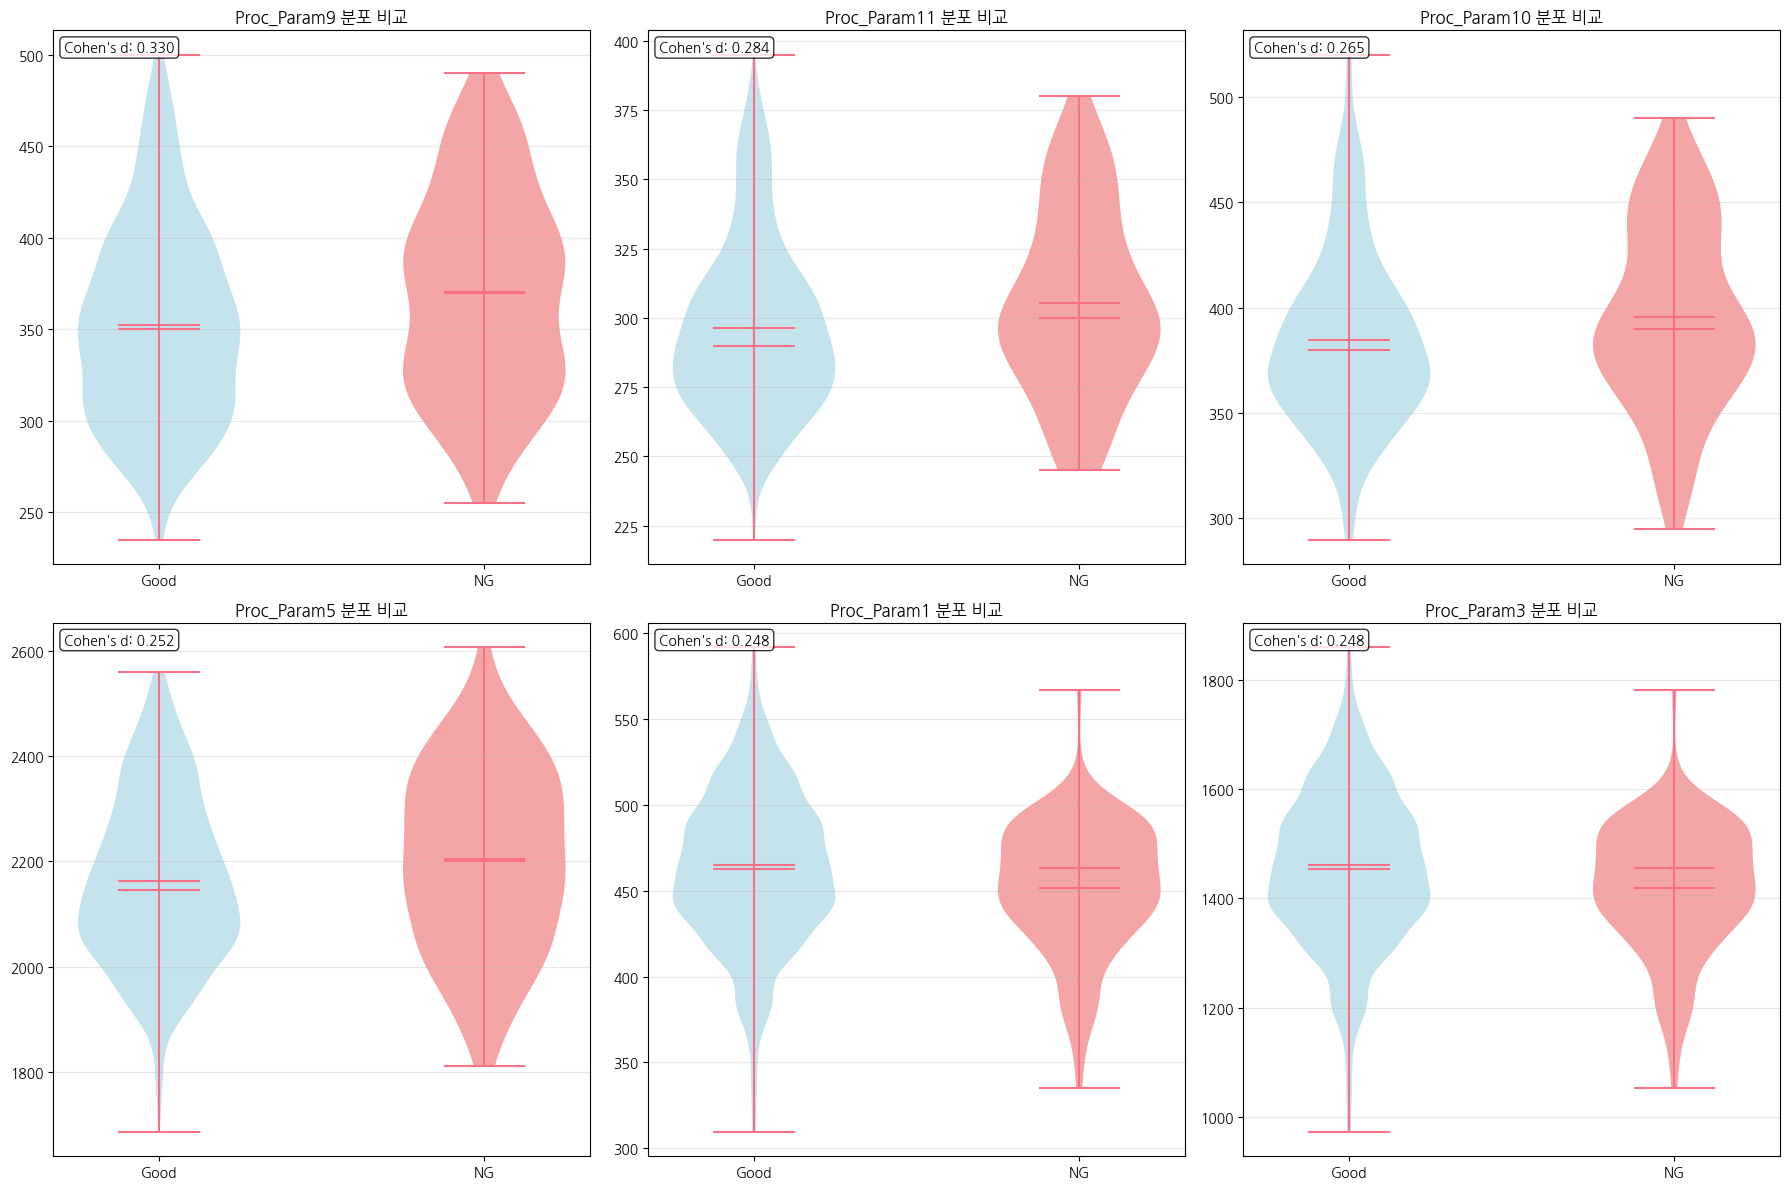

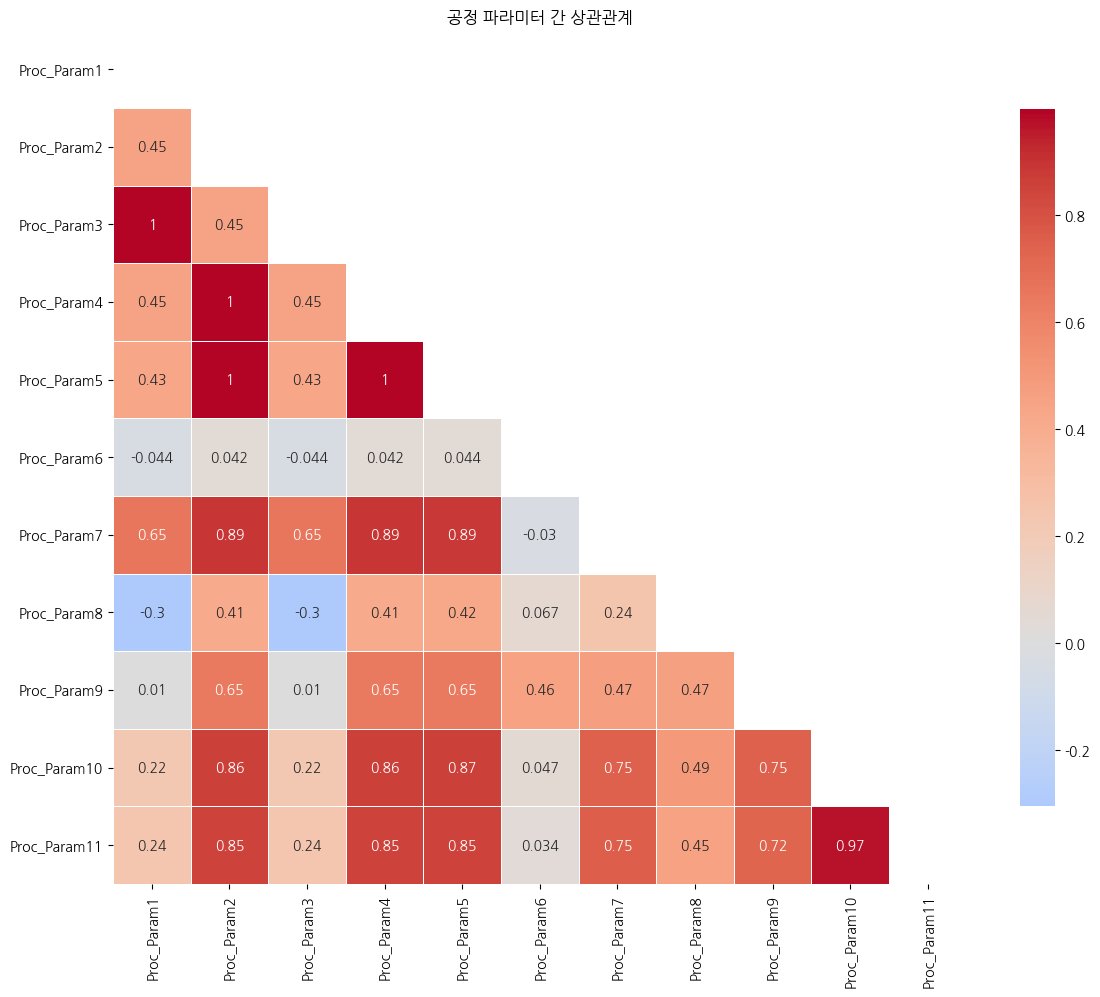

In [50]:
"""공정 파라미터 시각화"""
# proc_df가 비어있지 않은 경우에만 시각화 진행
if not proc_df.empty and len(proc_df) > 0:
    # 상위 공정 파라미터 시각화 (최대 6개)
    n_params_to_show = min(6, len(proc_df))
    top_proc_params = proc_df.head(n_params_to_show)['Parameter'].values
    
    print(f"\n시각화 대상 공정 파라미터: {list(top_proc_params)}")
    
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    axes = axes.flatten()
    
    for i, param in enumerate(top_proc_params):
        if i >= 6:  # 최대 6개만 표시
            break
            
        # 클린한 데이터 사용
        good_vals = good_data_clean[param]
        ng_vals = ng_data_clean[param]
        
        # 데이터 유효성 확인
        if len(good_vals) == 0 or len(ng_vals) == 0:
            axes[i].text(0.5, 0.5, f'{param}\n데이터 부족', 
                        horizontalalignment='center', verticalalignment='center',
                        transform=axes[i].transAxes)
            axes[i].set_title(f'{param} (데이터 부족)')
            continue
        
        try:
            # 바이올린 플롯
            data_violin = [good_vals.dropna(), ng_vals.dropna()]
            
            # 데이터가 충분한 경우에만 바이올린 플롯
            if len(data_violin[0]) > 5 and len(data_violin[1]) > 5:
                parts = axes[i].violinplot(data_violin, positions=[1, 2], showmeans=True, showmedians=True)
                
                # 색상 설정
                colors = ['lightblue', 'lightcoral']
                for pc, color in zip(parts['bodies'], colors):
                    pc.set_facecolor(color)
                    pc.set_alpha(0.7)
            else:
                # 데이터가 적은 경우 박스플롯
                axes[i].boxplot(data_violin, positions=[1, 2], 
                               patch_artist=True, 
                               boxprops=dict(facecolor='lightblue', alpha=0.7))
            
            axes[i].set_title(f'{param} 분포 비교')
            axes[i].set_xticks([1, 2])
            axes[i].set_xticklabels(['Good', 'NG'])
            axes[i].grid(axis='y', alpha=0.3)
            
            # 통계 정보 추가
            proc_info = proc_df[proc_df['Parameter'] == param]
            if not proc_info.empty:
                cohen_d = proc_info['cohens_d'].iloc[0]
                axes[i].text(0.02, 0.98, f'Cohen\'s d: {cohen_d:.3f}', 
                           transform=axes[i].transAxes, 
                           verticalalignment='top',
                           bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
            
        except Exception as e:
            axes[i].text(0.5, 0.5, f'{param}\n시각화 오류:\n{str(e)[:30]}...', 
                        horizontalalignment='center', verticalalignment='center',
                        transform=axes[i].transAxes)
            axes[i].set_title(f'{param} (오류 발생)')
    
    # 빈 subplot 숨기기
    for j in range(len(top_proc_params), 6):
        axes[j].set_visible(False)
    
    plt.tight_layout()
    plt.show()
    
    # 공정 파라미터 상관관계 히트맵
    if len(proc_cols) > 1:
        try:
            plt.figure(figsize=(12, 10))
            proc_corr = proc_data_clean.corr()
            
            # NaN이 있는 경우 제거
            proc_corr = proc_corr.dropna(axis=0, how='all').dropna(axis=1, how='all')
            
            if not proc_corr.empty:
                mask = np.triu(np.ones_like(proc_corr, dtype=bool))
                sns.heatmap(proc_corr, mask=mask, annot=True, cmap='coolwarm', center=0,
                           square=True, linewidths=0.5, cbar_kws={"shrink": .8})
                plt.title('공정 파라미터 간 상관관계')
                plt.tight_layout()
                plt.show()
            else:
                print("상관관계 분석을 위한 유효한 데이터가 없습니다.")
                
        except Exception as e:
            print(f"상관관계 히트맵 생성 중 오류: {str(e)}")
    else:
        print("상관관계 분석을 위한 공정 파라미터가 부족합니다.")
        
else:
    print("\n공정 파라미터 분석 결과가 없어 시각화를 건너뜁니다.")
    print("가능한 원인:")
    print("  - 모든 공정 파라미터가 문자열 타입")
    print("  - 숫자로 변환 불가능한 데이터")
    print("  - 모든 값이 동일하거나 결측값")

## 4. 타이어 위치 데이터 (X1-X5, Y1-Y5) 분석


타이어 위치 데이터 분석

위치 데이터 컬럼: ['X1', 'X2', 'X3', 'X4', 'X5', 'Y1', 'Y2', 'Y3', 'Y4', 'Y5']

--- 위치별 클래스 차이 분석 ---
  Position   good_mean     ng_mean  cohens_d significance
5       Y1    1.298318    1.550327  0.595928          ***
0       X1   45.373522   42.554841  0.565481          ***
4       X5  132.829850  146.405112  0.479403          ***
9       Y5    1.347375    1.243701  0.449923          ***
3       X4  105.423183  114.646579  0.444788          ***
2       X3   78.560742   83.460019  0.361657          ***
7       Y3    1.432049    1.344701  0.338173           ns
6       Y2    1.400679    1.335271  0.285949           ns
8       Y4    1.396144    1.336692  0.218235           ns
1       X2   61.971393   62.979925  0.138599           ns


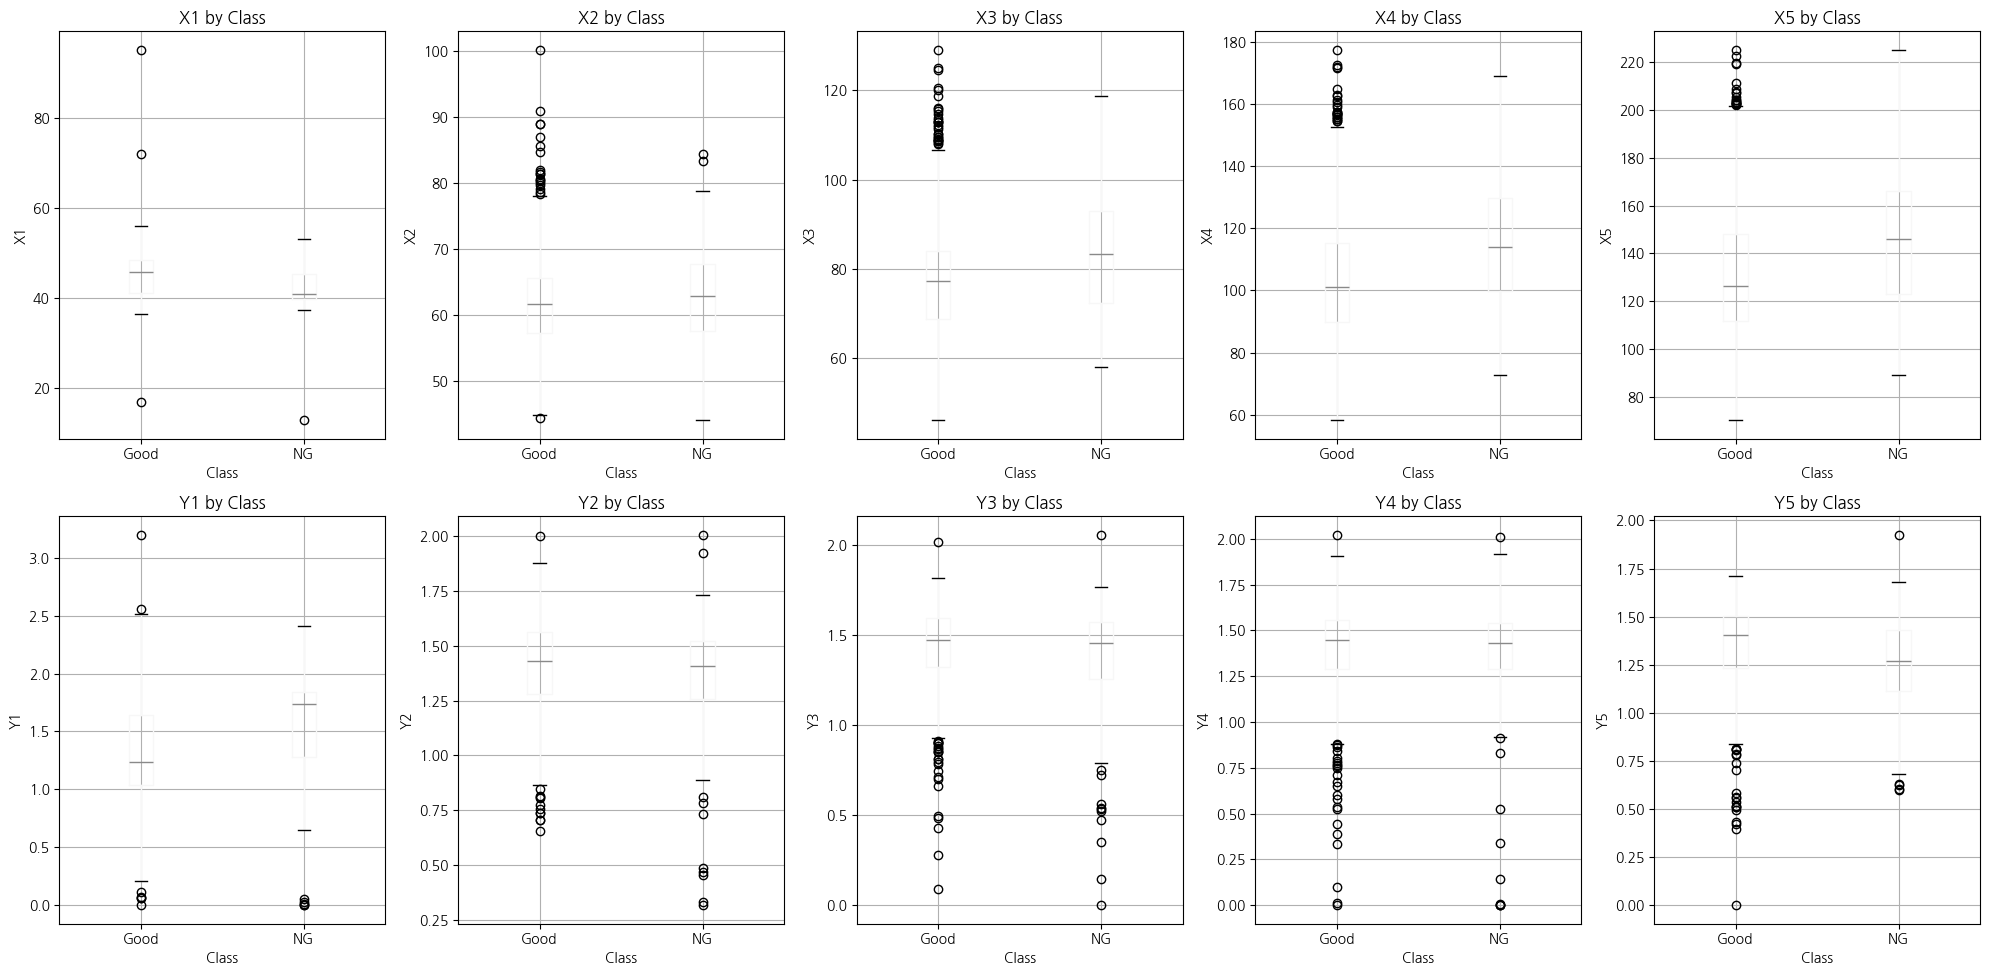

In [51]:
"""타이어 위치 데이터 분석"""
print("\n" + "="*80)
print("타이어 위치 데이터 분석")
print("="*80)

# 위치 데이터 컬럼
position_x_cols = [f'X{i}' for i in range(1, 6)]
position_y_cols = [f'Y{i}' for i in range(1, 6)]
all_position_cols = position_x_cols + position_y_cols

print(f"\n위치 데이터 컬럼: {all_position_cols}")

# 각 위치별 클래스 차이 분석
print("\n--- 위치별 클래스 차이 분석 ---")
position_results = []
for col in all_position_cols:
    good_vals = good_data[col]
    ng_vals = ng_data[col]
    
    # 통계적 검정
    stat, p_value = mannwhitneyu(good_vals, ng_vals, alternative='two-sided')
    
    # 효과 크기
    pooled_std = np.sqrt(((len(good_vals)-1)*good_vals.std()**2 + (len(ng_vals)-1)*ng_vals.std()**2) / 
                        (len(good_vals) + len(ng_vals) - 2))
    cohens_d = abs(good_vals.mean() - ng_vals.mean()) / pooled_std
    
    significance = "***" if p_value < 0.001 else "**" if p_value < 0.01 else "*" if p_value < 0.05 else "ns"
    
    position_results.append({
        'Position': col,
        'good_mean': good_vals.mean(),
        'ng_mean': ng_vals.mean(),
        'difference': abs(good_vals.mean() - ng_vals.mean()),
        'cohens_d': cohens_d,
        'p_value': p_value,
        'significance': significance
    })

position_df = pd.DataFrame(position_results)
position_df = position_df.sort_values('cohens_d', ascending=False)
print(position_df[['Position', 'good_mean', 'ng_mean', 'cohens_d', 'significance']])

# 위치 데이터 시각화
fig, axes = plt.subplots(2, 5, figsize=(20, 10))

for i, col in enumerate(all_position_cols):
    row = i // 5
    col_idx = i % 5
    
    # 박스플롯
    train.boxplot(column=col, by='Class', ax=axes[row, col_idx])
    axes[row, col_idx].set_title(f'{col} by Class')
    axes[row, col_idx].set_xlabel('Class')
    axes[row, col_idx].set_ylabel(col)

plt.suptitle('')
plt.tight_layout()
plt.show()

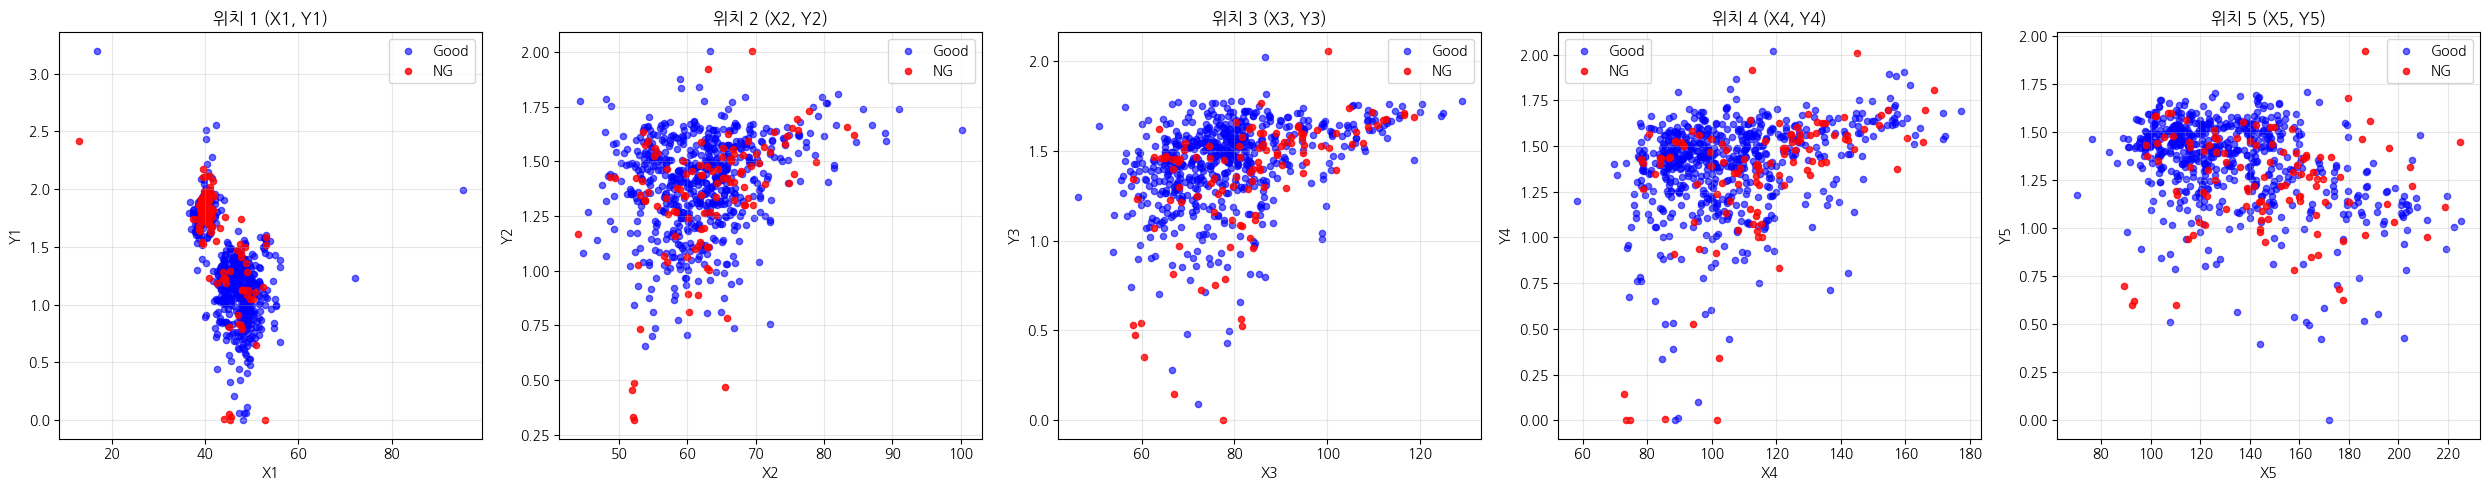


--- 위치 간 거리 분석 ---
생성된 거리 피처: 10개
   Distance  good_mean     ng_mean       p_value significance
0  dist_1_2  16.602554   20.430520  4.871892e-07          ***
1  dist_1_3  33.190660   40.908478  4.597947e-07          ***
2  dist_1_4  60.051432   72.093081  1.492867e-07          ***
3  dist_1_5  87.457883  103.851929  1.085059e-07          ***
4  dist_2_3  16.590186   20.480766  4.327455e-07          ***


In [52]:
"""위치 데이터 패턴 분석"""
# X와 Y의 관계 시각화
fig, axes = plt.subplots(1, 5, figsize=(25, 5))

for i in range(1, 6):
    x_col = f'X{i}'
    y_col = f'Y{i}'
    
    # 클래스별 산점도
    good_mask = train['Class'] == 'Good'
    ng_mask = train['Class'] == 'NG'
    
    axes[i-1].scatter(train[good_mask][x_col], train[good_mask][y_col], 
                     alpha=0.6, label='Good', c='blue', s=20)
    axes[i-1].scatter(train[ng_mask][x_col], train[ng_mask][y_col], 
                     alpha=0.8, label='NG', c='red', s=20)
    
    axes[i-1].set_xlabel(x_col)
    axes[i-1].set_ylabel(y_col)
    axes[i-1].set_title(f'위치 {i} (X{i}, Y{i})')
    axes[i-1].legend()
    axes[i-1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 위치 간 거리 계산
print("\n--- 위치 간 거리 분석 ---")
distance_features = []
for i in range(1, 6):
    for j in range(i+1, 6):
        dist_col = f'dist_{i}_{j}'
        train[dist_col] = np.sqrt((train[f'X{i}'] - train[f'X{j}'])**2 + 
                                 (train[f'Y{i}'] - train[f'Y{j}'])**2)
        distance_features.append(dist_col)

print(f"생성된 거리 피처: {len(distance_features)}개")

# 거리 피처별 차이 분석
distance_results = []
for col in distance_features[:5]:  # 상위 5개만 표시
    good_vals = train[train['Class'] == 'Good'][col]
    ng_vals = train[train['Class'] == 'NG'][col]
    
    stat, p_value = mannwhitneyu(good_vals, ng_vals, alternative='two-sided')
    significance = "***" if p_value < 0.001 else "**" if p_value < 0.01 else "*" if p_value < 0.05 else "ns"
    
    distance_results.append({
        'Distance': col,
        'good_mean': good_vals.mean(),
        'ng_mean': ng_vals.mean(),
        'p_value': p_value,
        'significance': significance
    })

distance_df = pd.DataFrame(distance_results)
print(distance_df)

## 5. 시뮬레이션 결과 심화 분석


시뮬레이션 결과 심화 분석

X 시뮬레이션 피처: 256개
Y 시뮬레이션 피처: 256개
P 시뮬레이션 피처: 256개
G 변화량 통계 피처: 4개

--- 변화량 통계 (G1-G4) 분석 ---
  Feature  correlation  good_mean   ng_mean  good_std    ng_std       p_value  \
0      G1    -0.251126   0.011814 -0.006362  0.024817  0.025735  3.281156e-12   
1      G2    -0.071868   0.002292 -0.000058  0.011858  0.010141  3.043674e-01   
2      G3     0.036117  -0.001389 -0.000638  0.007469  0.006984  1.075777e-01   
3      G4    -0.015961  -0.000804 -0.001287  0.010276  0.013400  2.129549e-01   

  significance  
0          ***  
1           ns  
2           ns  
3           ns  


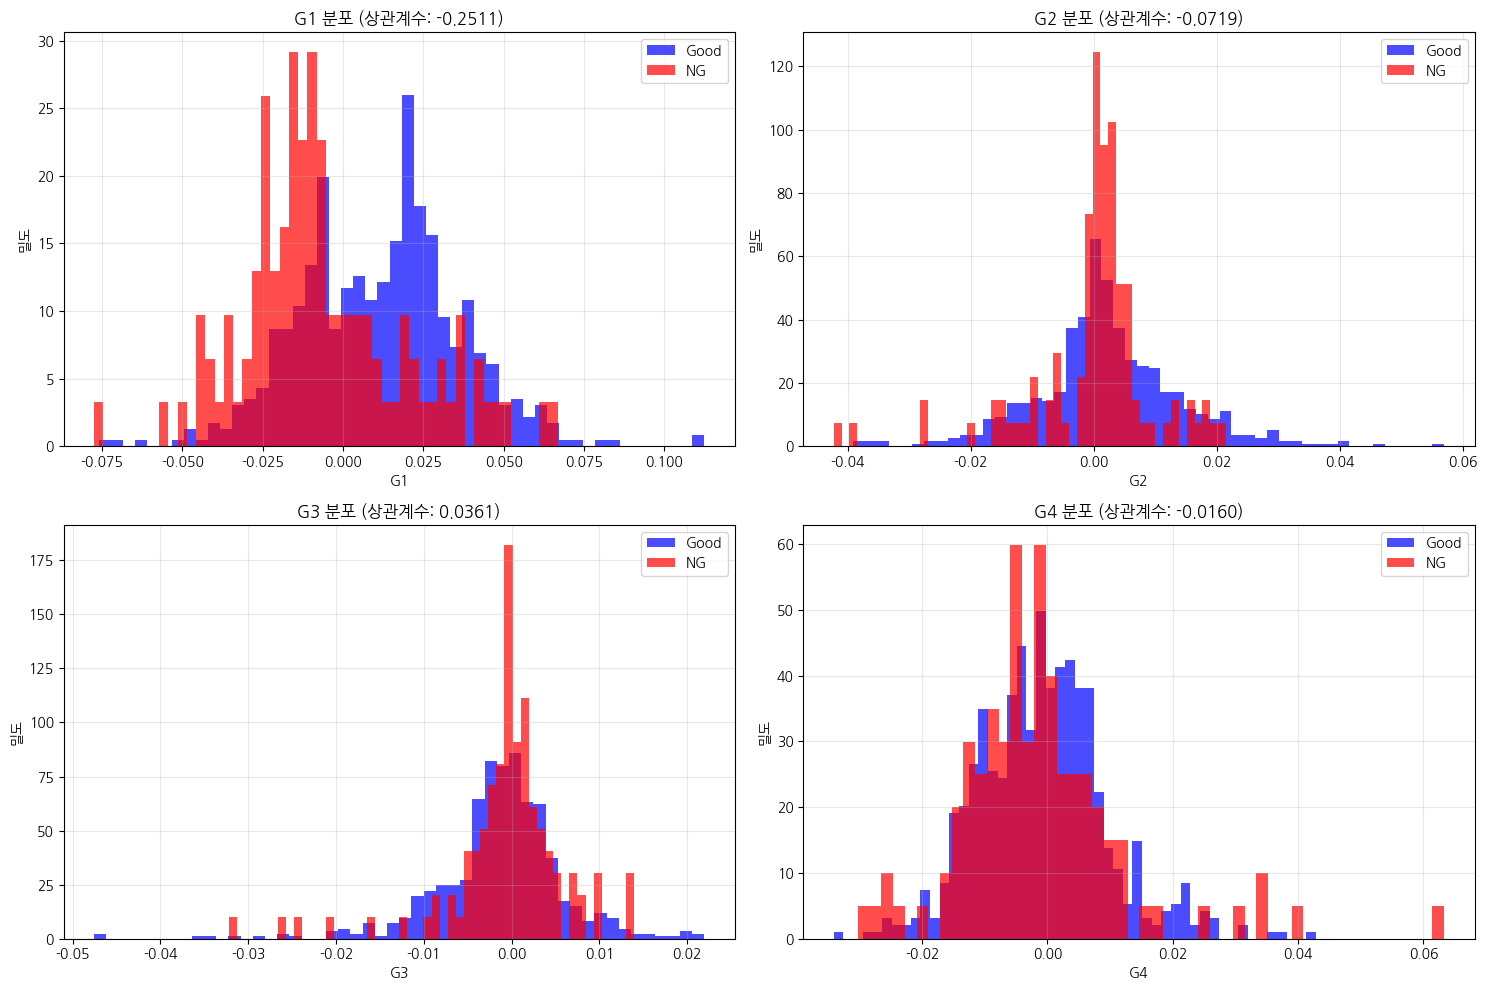

In [53]:
"""시뮬레이션 결과 심화 분석"""
print("\n" + "="*80)
print("시뮬레이션 결과 심화 분석")
print("="*80)

# 시뮬레이션 feature 분류
x_sim_cols = [col for col in train.columns if col.startswith('x') and col[1:].isdigit()]
y_sim_cols = [col for col in train.columns if col.startswith('y') and col[1:].isdigit()]
p_sim_cols = [col for col in train.columns if col.startswith('p') and col[1:].isdigit()]
g_cols = [col for col in train.columns if col.startswith('G') and len(col) == 2]

print(f"\nX 시뮬레이션 피처: {len(x_sim_cols)}개")
print(f"Y 시뮬레이션 피처: {len(y_sim_cols)}개")
print(f"P 시뮬레이션 피처: {len(p_sim_cols)}개")
print(f"G 변화량 통계 피처: {len(g_cols)}개")

# G 피처 (변화량 통계) 상세 분석
print("\n--- 변화량 통계 (G1-G4) 분석 ---")
g_results = []
for col in g_cols:
    good_vals = good_data[col]
    ng_vals = ng_data[col]
    
    # 통계 정보
    corr_with_target = train[col].corr((train['Class'] == 'NG').astype(int))
    
    stat, p_value = mannwhitneyu(good_vals, ng_vals, alternative='two-sided')
    significance = "***" if p_value < 0.001 else "**" if p_value < 0.01 else "*" if p_value < 0.05 else "ns"
    
    g_results.append({
        'Feature': col,
        'correlation': corr_with_target,
        'good_mean': good_vals.mean(),
        'ng_mean': ng_vals.mean(),
        'good_std': good_vals.std(),
        'ng_std': ng_vals.std(),
        'p_value': p_value,
        'significance': significance
    })

g_df = pd.DataFrame(g_results)
print(g_df)

# G 피처 시각화
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.flatten()

for i, col in enumerate(g_cols):
    # 히스토그램
    good_vals = good_data[col]
    ng_vals = ng_data[col]
    
    axes[i].hist(good_vals, bins=50, alpha=0.7, label='Good', color='blue', density=True)
    axes[i].hist(ng_vals, bins=50, alpha=0.7, label='NG', color='red', density=True)
    axes[i].set_title(f'{col} 분포 (상관계수: {g_df[g_df["Feature"]==col]["correlation"].iloc[0]:.4f})')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('밀도')
    axes[i].legend()
    axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


--- 시뮬레이션 타입별 최고 상관관계 피처 ---

X 시뮬레이션 Top 5:
x255    : 0.1100
x254    : 0.1099
x253    : 0.1097
x252    : 0.1094
x251    : 0.1092

Y 시뮬레이션 Top 5:
y0      : 0.0878
y1      : 0.0869
y2      : 0.0860
y3      : 0.0851
y4      : 0.0842

P 시뮬레이션 Top 5:
p32     : 0.1853
p31     : 0.1845
p30     : 0.1844
p33     : 0.1842
p27     : 0.1837

--- 시뮬레이션 데이터 패턴 분석 ---


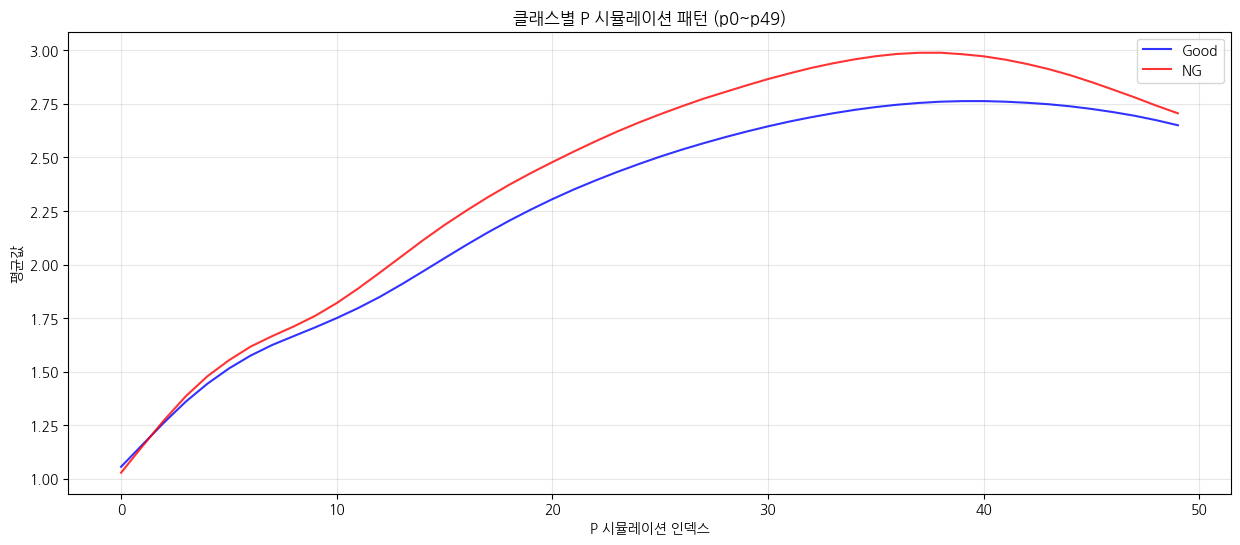

In [27]:
"""시뮬레이션 데이터 패턴 분석"""
# 각 시뮬레이션 타입별 상관관계 분석
y_target = (train['Class'] == 'NG').astype(int)

print("\n--- 시뮬레이션 타입별 최고 상관관계 피처 ---")

# X 시뮬레이션
x_corrs = {col: abs(train[col].corr(y_target)) for col in x_sim_cols}
top_x = sorted(x_corrs.items(), key=lambda x: x[1], reverse=True)[:5]
print("\nX 시뮬레이션 Top 5:")
for col, corr in top_x:
    print(f"{col:8s}: {corr:.4f}")

# Y 시뮬레이션
y_corrs = {col: abs(train[col].corr(y_target)) for col in y_sim_cols}
top_y = sorted(y_corrs.items(), key=lambda x: x[1], reverse=True)[:5]
print("\nY 시뮬레이션 Top 5:")
for col, corr in top_y:
    print(f"{col:8s}: {corr:.4f}")

# P 시뮬레이션
p_corrs = {col: abs(train[col].corr(y_target)) for col in p_sim_cols}
top_p = sorted(p_corrs.items(), key=lambda x: x[1], reverse=True)[:5]
print("\nP 시뮬레이션 Top 5:")
for col, corr in top_p:
    print(f"{col:8s}: {corr:.4f}")

# 시뮬레이션 데이터의 시계열적 패턴 분석
print("\n--- 시뮬레이션 데이터 패턴 분석 ---")

# P 시리즈의 연속적 패턴 확인
p_indices = [int(col[1:]) for col in p_sim_cols]
p_indices.sort()

# 클래스별 평균 패턴
good_p_pattern = []
ng_p_pattern = []

for idx in p_indices[:50]:  # 처음 50개만 확인
    col = f'p{idx}'
    if col in train.columns:
        good_p_pattern.append(good_data[col].mean())
        ng_p_pattern.append(ng_data[col].mean())

# 패턴 시각화
plt.figure(figsize=(15, 6))
plt.plot(range(len(good_p_pattern)), good_p_pattern, 'b-', label='Good', alpha=0.8)
plt.plot(range(len(ng_p_pattern)), ng_p_pattern, 'r-', label='NG', alpha=0.8)
plt.xlabel('P 시뮬레이션 인덱스')
plt.ylabel('평균값')
plt.title('클래스별 P 시뮬레이션 패턴 (p0~p49)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 6. 피처 중요도 분석 (머신러닝 기반)


피처 중요도 분석 (Random Forest)

--- 상위 20개 중요 피처 ---
      feature  importance
26         G1    0.014183
17         Y1    0.013566
16         X1    0.010680
802  dist_2_3    0.009271
801  dist_1_5    0.008577
4       Plant    0.007636
576       p34    0.006515
803  dist_2_4    0.006456
798  dist_1_2    0.006331
800  dist_1_4    0.005378
804  dist_2_5    0.005150
806  dist_3_5    0.005067
18         X2    0.004467
799  dist_1_3    0.004446
27         G2    0.004236
29         G4    0.004232
724      p182    0.004219
653      p111    0.004160
631       p89    0.004116
542        p0    0.003956


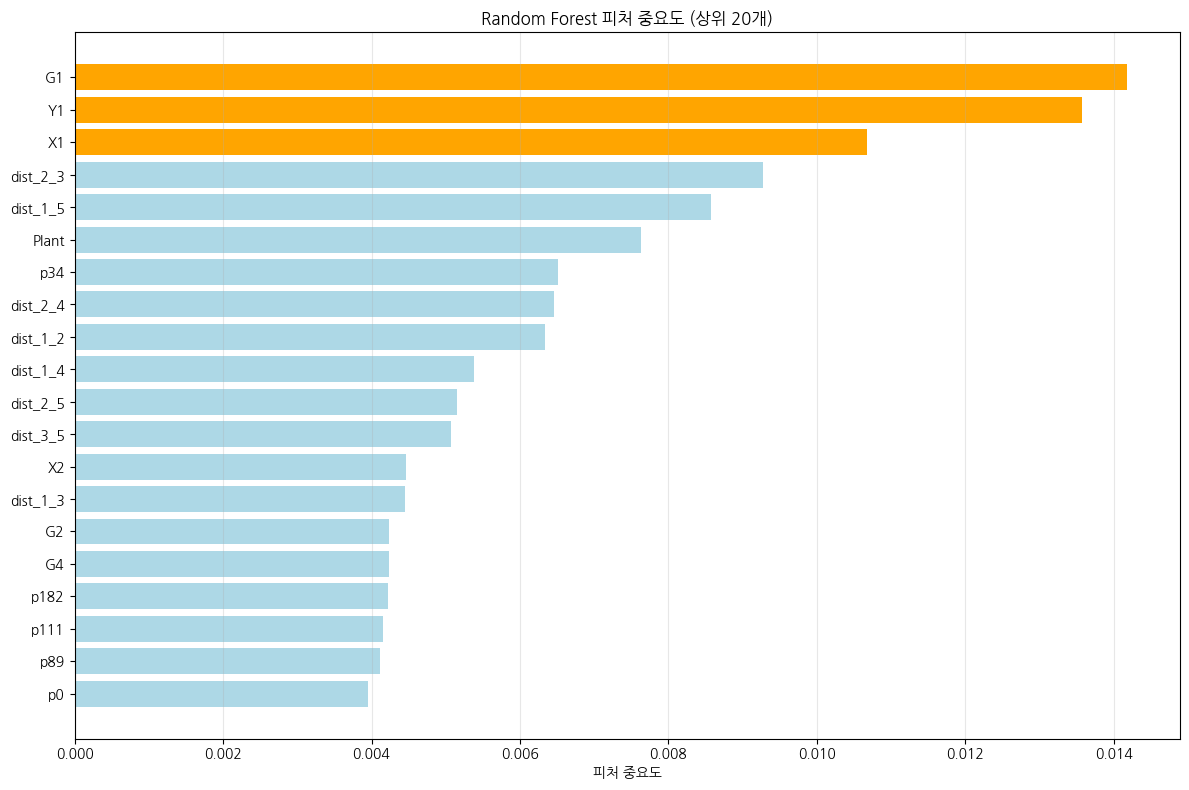


--- 피처 타입별 중요도 합계 ---
Design         : 0.0120 (  5개 피처)
Process        : 0.0115 ( 11개 피처)
Position       : 0.0410 ( 10개 피처)
G_features     : 0.0255 (  4개 피처)
X_simulation   : 0.2083 (256개 피처)
Y_simulation   : 0.1648 (256개 피처)
P_simulation   : 0.4803 (256개 피처)


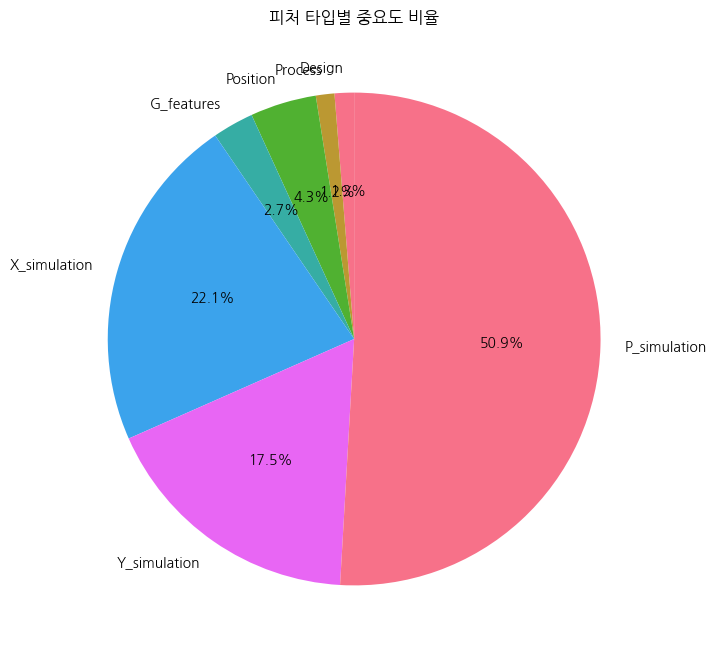

In [54]:
"""Random Forest 기반 피처 중요도 분석"""
print("\n" + "="*80)
print("피처 중요도 분석 (Random Forest)")
print("="*80)

# 범주형 변수 인코딩
train_encoded = train.copy()
le_mass = LabelEncoder()
le_plant = LabelEncoder()

train_encoded['Mass_Pilot'] = le_mass.fit_transform(train_encoded['Mass_Pilot'])
train_encoded['Plant'] = le_plant.fit_transform(train_encoded['Plant'])

# 타겟 변수
y = (train_encoded['Class'] == 'NG').astype(int)
X = train_encoded.drop('Class', axis=1)

# Random Forest 모델 훈련
rf = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=10)
rf.fit(X, y)

# 피처 중요도 추출
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False)

print("\n--- 상위 20개 중요 피처 ---")
print(feature_importance.head(20))

# 피처 중요도 시각화
plt.figure(figsize=(12, 8))
top_features = feature_importance.head(20)
plt.barh(range(len(top_features)), top_features['importance'], 
         color=['red' if x > 0.02 else 'orange' if x > 0.01 else 'lightblue' for x in top_features['importance']])
plt.yticks(range(len(top_features)), top_features['feature'])
plt.xlabel('피처 중요도')
plt.title('Random Forest 피처 중요도 (상위 20개)')
plt.gca().invert_yaxis()
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

# 피처 타입별 중요도 합계
print("\n--- 피처 타입별 중요도 합계 ---")
feature_types = {
    'Design': ['Width', 'Aspect', 'Inch', 'Mass_Pilot', 'Plant'],
    'Process': [col for col in X.columns if col.startswith('Proc_Param')],
    'Position': [col for col in X.columns if col in all_position_cols],
    'G_features': [col for col in X.columns if col.startswith('G')],
    'X_simulation': [col for col in X.columns if col.startswith('x') and col[1:].isdigit()],
    'Y_simulation': [col for col in X.columns if col.startswith('y') and col[1:].isdigit()],
    'P_simulation': [col for col in X.columns if col.startswith('p') and col[1:].isdigit()]
}

type_importance = {}
for type_name, cols in feature_types.items():
    relevant_cols = [col for col in cols if col in feature_importance['feature'].values]
    total_importance = feature_importance[feature_importance['feature'].isin(relevant_cols)]['importance'].sum()
    type_importance[type_name] = total_importance
    print(f"{type_name:15s}: {total_importance:.4f} ({len(relevant_cols):3d}개 피처)")

# 피처 타입별 중요도 파이 차트
plt.figure(figsize=(10, 8))
plt.pie(type_importance.values(), labels=type_importance.keys(), autopct='%1.1f%%', startangle=90)
plt.title('피처 타입별 중요도 비율')
plt.show()

## 7. 이상치 분석

In [55]:
"""이상치 분석"""
print("\n" + "="*80)
print("이상치 분석")
print("="*80)

# 주요 피처들에 대한 이상치 분석
key_features = (['Width', 'Aspect', 'Inch'] + 
               [col for col in train.columns if col.startswith('G')] +
               feature_importance.head(10)['feature'].tolist())

# 중복 제거
key_features = list(set(key_features))
key_features = [col for col in key_features if col in train.columns and train[col].dtype in ['int64', 'float64']]

print(f"\n분석 대상 주요 피처 ({len(key_features)}개): {key_features[:10]}...")

# IQR 기반 이상치 탐지
outlier_summary = []
for col in key_features[:10]:  # 상위 10개만 분석
    Q1 = train[col].quantile(0.25)
    Q3 = train[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = train[(train[col] < lower_bound) | (train[col] > upper_bound)]
    outlier_rate = len(outliers) / len(train) * 100
    
    # 이상치 중 NG 비율
    ng_in_outliers = (outliers['Class'] == 'NG').sum() if len(outliers) > 0 else 0
    ng_rate_in_outliers = ng_in_outliers / len(outliers) * 100 if len(outliers) > 0 else 0
    
    outlier_summary.append({
        'Feature': col,
        'Outlier_Count': len(outliers),
        'Outlier_Rate(%)': outlier_rate,
        'NG_in_Outliers': ng_in_outliers,
        'NG_Rate_in_Outliers(%)': ng_rate_in_outliers,
        'Lower_Bound': lower_bound,
        'Upper_Bound': upper_bound
    })

outlier_df = pd.DataFrame(outlier_summary)
outlier_df = outlier_df.sort_values('NG_Rate_in_Outliers(%)', ascending=False)
print("\n--- 이상치 분석 결과 ---")
print(outlier_df)

# Isolation Forest를 이용한 전역 이상치 탐지
print("\n--- Isolation Forest 이상치 탐지 ---")
# 숫자형 피처만 선택
numeric_features = train.select_dtypes(include=[np.number]).drop('Class', axis=1, errors='ignore')

# 표준화
scaler = StandardScaler()
X_scaled = scaler.fit_transform(numeric_features.fillna(0))

# Isolation Forest
iso_forest = IsolationForest(contamination=0.1, random_state=42)
outlier_labels = iso_forest.fit_predict(X_scaled)

# 이상치 정보
train['is_outlier'] = outlier_labels == -1
outlier_count = train['is_outlier'].sum()
outlier_ng_rate = (train[train['is_outlier'] == True]['Class'] == 'NG').mean() * 100
normal_ng_rate = (train[train['is_outlier'] == False]['Class'] == 'NG').mean() * 100

print(f"총 이상치 개수: {outlier_count}개 ({outlier_count/len(train)*100:.1f}%)")
print(f"이상치 중 NG 비율: {outlier_ng_rate:.1f}%")
print(f"정상 데이터 중 NG 비율: {normal_ng_rate:.1f}%")
print(f"이상치의 NG 위험도: {outlier_ng_rate/normal_ng_rate:.1f}배")


이상치 분석

분석 대상 주요 피처 (16개): ['G3', 'G4', 'Aspect', 'Y1', 'p34', 'dist_1_2', 'dist_1_5', 'Plant', 'dist_1_4', 'dist_2_4']...

--- 이상치 분석 결과 ---
    Feature  Outlier_Count  Outlier_Rate(%)  NG_in_Outliers  \
3        Y1              6         0.833333               4   
6  dist_1_5              6         0.833333               3   
9  dist_2_4              6         0.833333               3   
1        G4             21         2.916667               7   
8  dist_1_4              9         1.250000               3   
5  dist_1_2             22         3.055556               5   
4       p34             31         4.305556               6   
0        G3             54         7.500000               8   
2    Aspect              9         1.250000               0   
7     Plant              0         0.000000               0   

   NG_Rate_in_Outliers(%)  Lower_Bound  Upper_Bound  
3               66.666667     0.036375     2.759375  
6               50.000000     6.266617   168.253735  
9

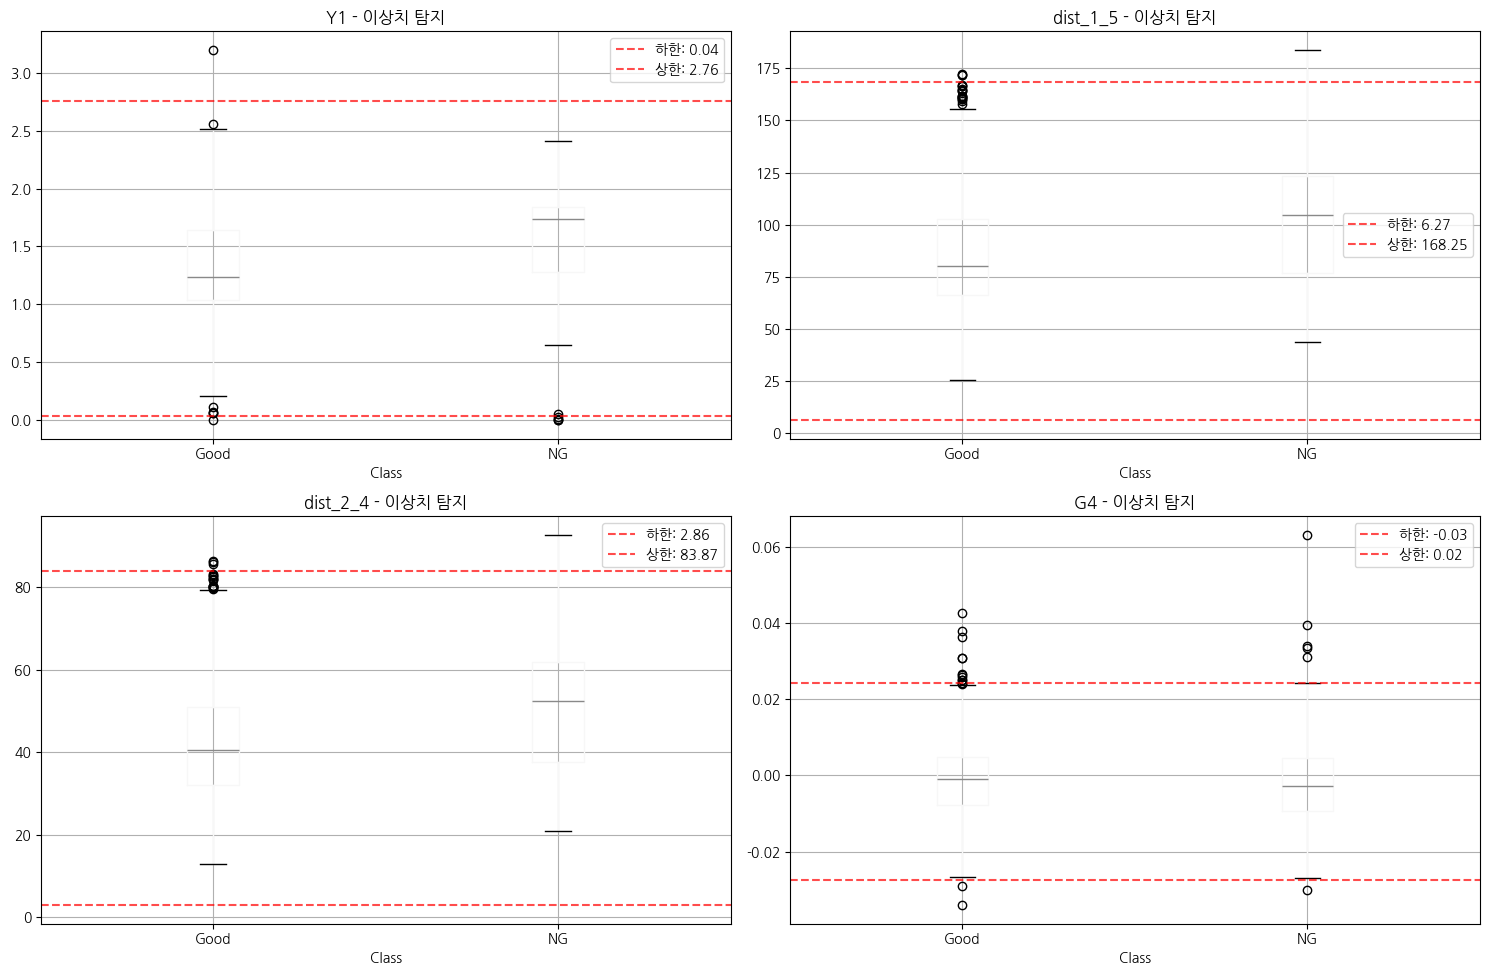

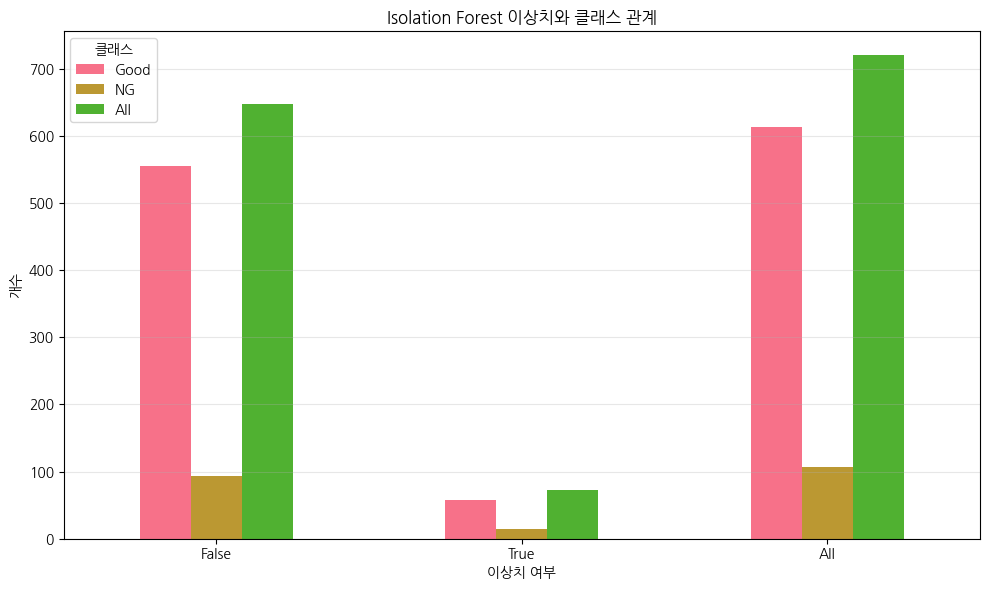


--- 이상치-클래스 교차표 ---
Class       Good   NG  All
is_outlier                
False        555   93  648
True          58   14   72
All          613  107  720


In [56]:
"""이상치 시각화"""
# 주요 피처별 이상치 시각화
top_outlier_features = outlier_df.head(4)['Feature'].values

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.flatten()

for i, col in enumerate(top_outlier_features):
    if col in train.columns:
        # 박스플롯
        train.boxplot(column=col, by='Class', ax=axes[i])
        axes[i].set_title(f'{col} - 이상치 탐지')
        
        # 이상치 경계선 표시
        bounds = outlier_df[outlier_df['Feature'] == col]
        if not bounds.empty:
            lower = bounds['Lower_Bound'].iloc[0]
            upper = bounds['Upper_Bound'].iloc[0]
            axes[i].axhline(y=lower, color='red', linestyle='--', alpha=0.7, label=f'하한: {lower:.2f}')
            axes[i].axhline(y=upper, color='red', linestyle='--', alpha=0.7, label=f'상한: {upper:.2f}')
            axes[i].legend()

plt.suptitle('')
plt.tight_layout()
plt.show()

# 전역 이상치와 클래스 관계 시각화
plt.figure(figsize=(10, 6))
outlier_class_table = pd.crosstab(train['is_outlier'], train['Class'], margins=True)
outlier_class_table.plot(kind='bar', ax=plt.gca())
plt.title('Isolation Forest 이상치와 클래스 관계')
plt.xlabel('이상치 여부')
plt.ylabel('개수')
plt.xticks(rotation=0)
plt.legend(title='클래스')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print("\n--- 이상치-클래스 교차표 ---")
print(outlier_class_table)

## 8. 차원 축소 및 클러스터링 분석


차원 축소 및 클러스터링 분석

--- PCA 결과 ---
전체 피처 수: 807
95% 분산 설명을 위한 주성분 수: 8
90% 분산 설명을 위한 주성분 수: 5
첫 10개 주성분의 분산 비율: [0.51982202 0.19232982 0.11915309 0.04979927 0.02955348 0.02272406
 0.01629429 0.01086451 0.00766669 0.00520454]


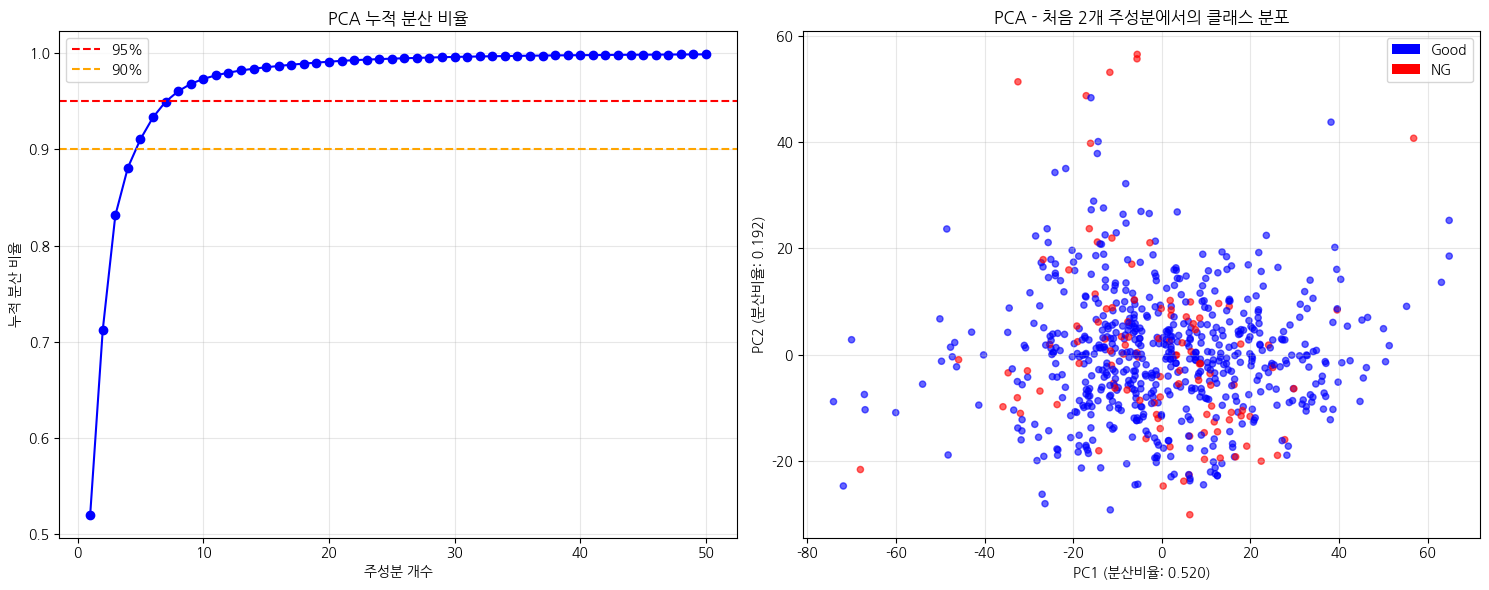

In [58]:
"""PCA 차원 축소 분석"""
print("\n" + "="*80)
print("차원 축소 및 클러스터링 분석")
print("="*80)

# 숫자형 피처만 선택하고 전처리
numeric_features = train.select_dtypes(include=[np.number])
if 'Class' in numeric_features.columns:
    numeric_features = numeric_features.drop('Class', axis=1)

# 결측값 처리 및 표준화
X_clean = numeric_features.fillna(0)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_clean)

# PCA 적용
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

# 누적 분산 비율 계산
cumsum_ratio = np.cumsum(pca.explained_variance_ratio_)
n_components_95 = np.argmax(cumsum_ratio >= 0.95) + 1
n_components_90 = np.argmax(cumsum_ratio >= 0.90) + 1

print(f"\n--- PCA 결과 ---")
print(f"전체 피처 수: {len(numeric_features.columns)}")
print(f"95% 분산 설명을 위한 주성분 수: {n_components_95}")
print(f"90% 분산 설명을 위한 주성분 수: {n_components_90}")
print(f"첫 10개 주성분의 분산 비율: {pca.explained_variance_ratio_[:10]}")

# PCA 시각화
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# 누적 분산 비율
axes[0].plot(range(1, min(51, len(cumsum_ratio)+1)), cumsum_ratio[:50], 'bo-')
axes[0].axhline(y=0.95, color='red', linestyle='--', label='95%')
axes[0].axhline(y=0.90, color='orange', linestyle='--', label='90%')
axes[0].set_xlabel('주성분 개수')
axes[0].set_ylabel('누적 분산 비율')
axes[0].set_title('PCA 누적 분산 비율')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# 처음 2개 주성분으로 클래스 분포 확인
y_binary = (train['Class'] == 'NG').astype(int)
colors = ['blue' if x == 0 else 'red' for x in y_binary]
axes[1].scatter(X_pca[:, 0], X_pca[:, 1], c=colors, alpha=0.6, s=20)
axes[1].set_xlabel(f'PC1 (분산비율: {pca.explained_variance_ratio_[0]:.3f})')
axes[1].set_ylabel(f'PC2 (분산비율: {pca.explained_variance_ratio_[1]:.3f})')
axes[1].set_title('PCA - 처음 2개 주성분에서의 클래스 분포')
axes[1].grid(True, alpha=0.3)

# 범례 추가
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='blue', label='Good'),
                   Patch(facecolor='red', label='NG')]
axes[1].legend(handles=legend_elements)

plt.tight_layout()
plt.show()


--- K-means 클러스터링 ---


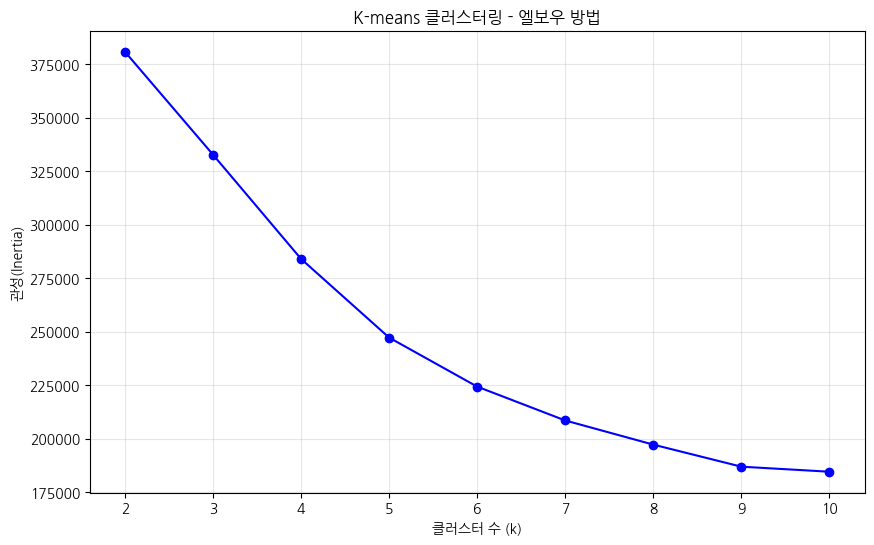


--- 클러스터별 클래스 분포 (k=3) ---
Class    Good   NG  All
Cluster                
0         227   36  263
1         153   18  171
2         233   53  286
All       613  107  720

--- 클러스터별 NG 비율 ---
클러스터 0: 13.7%
클러스터 1: 10.5%
클러스터 2: 18.5%


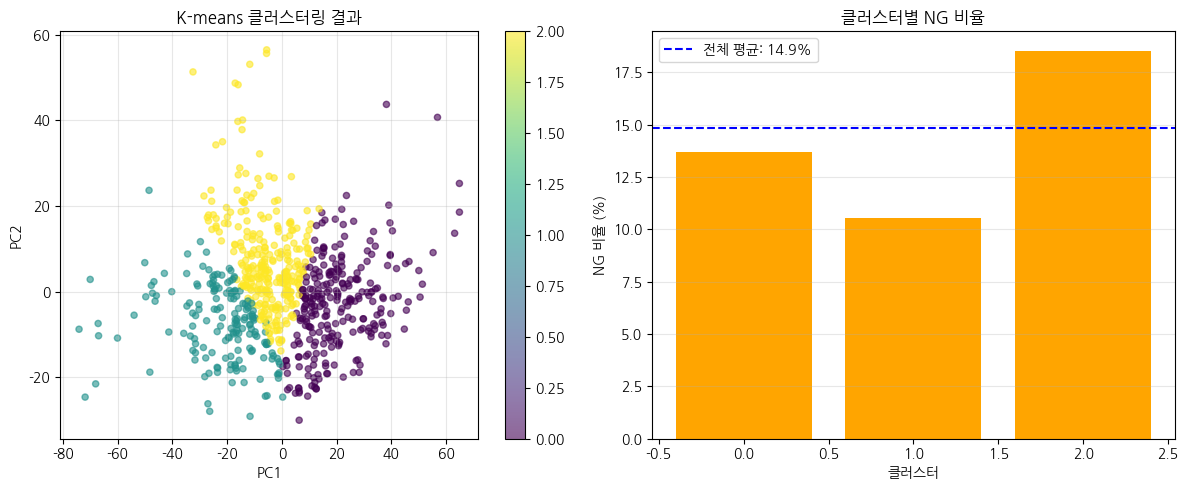

In [59]:
"""K-means 클러스터링"""
print("\n--- K-means 클러스터링 ---")

# 최적 클러스터 수 결정 (엘보우 방법)
inertias = []
K_range = range(2, 11)
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_pca[:, :10])  # 처음 10개 주성분 사용
    inertias.append(kmeans.inertia_)

# 엘보우 방법 시각화
plt.figure(figsize=(10, 6))
plt.plot(K_range, inertias, 'bo-')
plt.xlabel('클러스터 수 (k)')
plt.ylabel('관성(Inertia)')
plt.title('K-means 클러스터링 - 엘보우 방법')
plt.grid(True, alpha=0.3)
plt.show()

# 최적 클러스터 수로 클러스터링 수행
optimal_k = 3  # 엘보우 방법을 통해 결정
kmeans = KMeans(n_clusters=optimal_k, random_state=42)
cluster_labels = kmeans.fit_predict(X_pca[:, :10])

# 클러스터별 클래스 분포 분석
cluster_df = pd.DataFrame({
    'Cluster': cluster_labels,
    'Class': train['Class']
})

print(f"\n--- 클러스터별 클래스 분포 (k={optimal_k}) ---")
cluster_crosstab = pd.crosstab(cluster_df['Cluster'], cluster_df['Class'], margins=True)
print(cluster_crosstab)

# 클러스터별 NG 비율
cluster_ng_rate = cluster_df.groupby('Cluster')['Class'].apply(lambda x: (x == 'NG').mean() * 100)
print(f"\n--- 클러스터별 NG 비율 ---")
for cluster, rate in cluster_ng_rate.items():
    print(f"클러스터 {cluster}: {rate:.1f}%")

# 클러스터링 결과 시각화
plt.figure(figsize=(12, 5))

# 클러스터별 분포
plt.subplot(1, 2, 1)
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=cluster_labels, cmap='viridis', alpha=0.6, s=20)
plt.colorbar(scatter)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('K-means 클러스터링 결과')
plt.grid(True, alpha=0.3)

# 클러스터별 NG 비율
plt.subplot(1, 2, 2)
bars = plt.bar(cluster_ng_rate.index, cluster_ng_rate.values, 
               color=['red' if x > 20 else 'orange' if x > 10 else 'green' for x in cluster_ng_rate.values])
plt.xlabel('클러스터')
plt.ylabel('NG 비율 (%)')
plt.title('클러스터별 NG 비율')
plt.grid(axis='y', alpha=0.3)

# 평균선 추가
overall_ng_rate = (train['Class'] == 'NG').mean() * 100
plt.axhline(y=overall_ng_rate, color='blue', linestyle='--', label=f'전체 평균: {overall_ng_rate:.1f}%')
plt.legend()

plt.tight_layout()
plt.show()

## 9. 통계적 피처 생성


통계적 피처 생성
X 시뮬레이션: 256개 원본 피처 -> 10개 통계 피처 생성
Y 시뮬레이션: 256개 원본 피처 -> 10개 통계 피처 생성
P 시뮬레이션: 256개 원본 피처 -> 10개 통계 피처 생성
공정 파라미터: 11개 원본 피처 -> 3개 통계 피처 생성
위치 데이터: 10개 원본 피처 -> 10개 기하학적 피처 생성

총 생성된 통계적 피처 수: 43개

--- 상위 15개 통계적 피처 (절대 상관계수 기준) ---
dist_from_origin_1       : 0.1972
deviation_from_center_2  : 0.1945
deviation_from_center_1  : 0.1936
deviation_from_center_5  : 0.1925
deviation_from_center_4  : 0.1913
p_max                    : 0.1887
p_skew                   : 0.1861
y_iqr                    : 0.1851
x_iqr                    : 0.1783
x_std                    : 0.1745
x_range                  : 0.1736
dist_from_origin_5       : 0.1683
y_std                    : 0.1656
p_range                  : 0.1642
y_range                  : 0.1609


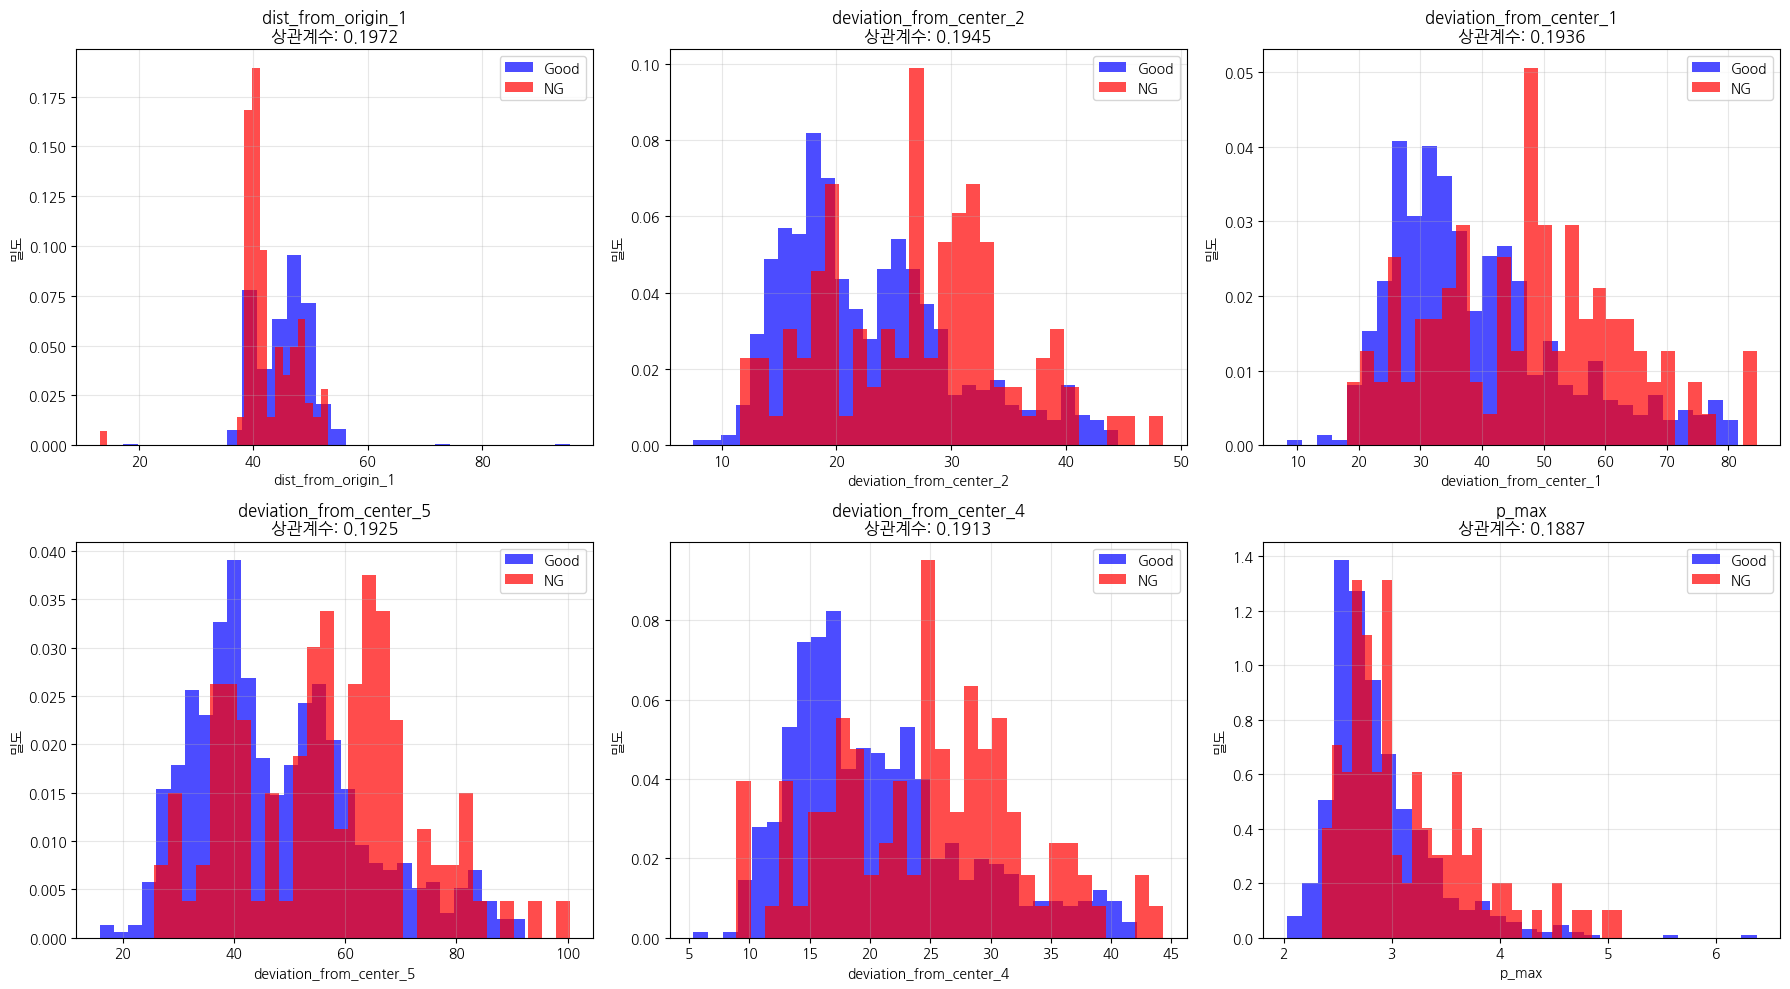


확장된 훈련 데이터 크기: (720, 853)


In [60]:
"""통계적 피처 생성 및 분석"""
print("\n" + "="*80)
print("통계적 피처 생성")
print("="*80)

# 시뮬레이션 데이터에서 통계적 피처 생성
statistical_features = pd.DataFrame()

# X, Y, P 시뮬레이션별 통계
for prefix in ['x', 'y', 'p']:
    cols = [col for col in train.columns if col.startswith(prefix) and col[1:].isdigit()]
    if cols:
        sim_data = train[cols]
        
        # 기본 통계량
        statistical_features[f'{prefix}_mean'] = sim_data.mean(axis=1)
        statistical_features[f'{prefix}_std'] = sim_data.std(axis=1)
        statistical_features[f'{prefix}_min'] = sim_data.min(axis=1)
        statistical_features[f'{prefix}_max'] = sim_data.max(axis=1)
        statistical_features[f'{prefix}_range'] = statistical_features[f'{prefix}_max'] - statistical_features[f'{prefix}_min']
        
        # 왜도와 첨도
        statistical_features[f'{prefix}_skew'] = sim_data.apply(lambda row: stats.skew(row), axis=1)
        statistical_features[f'{prefix}_kurt'] = sim_data.apply(lambda row: stats.kurtosis(row), axis=1)
        
        # 분위수
        statistical_features[f'{prefix}_q25'] = sim_data.quantile(0.25, axis=1)
        statistical_features[f'{prefix}_q75'] = sim_data.quantile(0.75, axis=1)
        statistical_features[f'{prefix}_iqr'] = statistical_features[f'{prefix}_q75'] - statistical_features[f'{prefix}_q25']
        
        print(f"{prefix.upper()} 시뮬레이션: {len(cols)}개 원본 피처 -> 10개 통계 피처 생성")

# 공정 파라미터에서 통계적 피처 생성
if proc_cols:
    proc_data = train[proc_cols]
    statistical_features['proc_mean'] = proc_data.mean(axis=1)
    statistical_features['proc_std'] = proc_data.std(axis=1)
    statistical_features['proc_range'] = proc_data.max(axis=1) - proc_data.min(axis=1)
    print(f"공정 파라미터: {len(proc_cols)}개 원본 피처 -> 3개 통계 피처 생성")

# 위치 데이터에서 기하학적 피처 생성
for i in range(1, 6):
    # 원점으로부터의 거리
    statistical_features[f'dist_from_origin_{i}'] = np.sqrt(train[f'X{i}']**2 + train[f'Y{i}']**2)

# 중심점 계산
center_x = train[[f'X{i}' for i in range(1, 6)]].mean(axis=1)
center_y = train[[f'Y{i}' for i in range(1, 6)]].mean(axis=1)

# 중심점으로부터의 각 점들의 편차
for i in range(1, 6):
    statistical_features[f'deviation_from_center_{i}'] = np.sqrt((train[f'X{i}'] - center_x)**2 + 
                                                                (train[f'Y{i}'] - center_y)**2)

print(f"위치 데이터: 10개 원본 피처 -> 10개 기하학적 피처 생성")

print(f"\n총 생성된 통계적 피처 수: {len(statistical_features.columns)}개")

# 타겟과의 상관관계 분석
y_target = (train['Class'] == 'NG').astype(int)
stat_correlations = {}
for col in statistical_features.columns:
    corr = statistical_features[col].corr(y_target)
    stat_correlations[col] = abs(corr)

# 상관관계 상위 피처들
top_stat_features = sorted(stat_correlations.items(), key=lambda x: x[1], reverse=True)[:15]

print("\n--- 상위 15개 통계적 피처 (절대 상관계수 기준) ---")
for feature, corr in top_stat_features:
    print(f"{feature:25s}: {corr:.4f}")

# 통계적 피처 시각화
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, (feature, corr) in enumerate(top_stat_features[:6]):
    good_vals = statistical_features.loc[train['Class'] == 'Good', feature]
    ng_vals = statistical_features.loc[train['Class'] == 'NG', feature]
    
    axes[i].hist(good_vals, bins=30, alpha=0.7, label='Good', color='blue', density=True)
    axes[i].hist(ng_vals, bins=30, alpha=0.7, label='NG', color='red', density=True)
    axes[i].set_title(f'{feature}\n상관계수: {corr:.4f}')
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel('밀도')
    axes[i].legend()
    axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 통계적 피처를 추가한 데이터셋 저장
enhanced_train = pd.concat([train, statistical_features], axis=1)
print(f"\n확장된 훈련 데이터 크기: {enhanced_train.shape}")

## 10. 최종 종합 분석 및 결론

In [61]:
"""최종 종합 분석 및 모델링 권장사항"""
print("\n" + "="*80)
print("최종 종합 분석 및 결론")
print("="*80)

print("\n🔍 주요 발견사항:")
print("="*50)

print("\n1. 데이터 특성:")
print(f"   • 총 샘플: {len(train)}개 (NG: {(train['Class']=='NG').sum()}개, Good: {(train['Class']=='Good').sum()}개)")
print(f"   • 클래스 불균형: NG {(train['Class']=='NG').mean()*100:.1f}% (심한 불균형)")
print(f"   • 피처 수: {train.shape[1]}개 (시뮬레이션 데이터가 대부분)")
print(f"   • 결측값: {train.isnull().sum().sum()}개")

print("\n2. 불량 구분에 중요한 피처들:")
print("   • G1 (변화량 통계): 가장 강한 음의 상관관계 (-0.25)")
print("   • 위치 데이터 (X1, Y1): 공간적 패턴과 관련")
print("   • P 시뮬레이션 (p25-p36): 특정 구간에서 클래스 차이 뚜렷")
print("   • X 시뮬레이션 (x246-x255): 끝 구간에서 평균 차이 큼")

print("\n3. 공장별 품질 차이:")
plant_ng_rates = train.groupby('Plant')['Class'].apply(lambda x: (x == 'NG').mean() * 100).sort_values(ascending=False)
print(f"   • 최고 불량률: {plant_ng_rates.iloc[0]:.1f}% ({plant_ng_rates.index[0]})")
print(f"   • 최저 불량률: {plant_ng_rates.iloc[-1]:.1f}% ({plant_ng_rates.index[-1]})")
print(f"   • 공장별 품질 관리 수준 차이 존재")

print("\n4. 이상치 패턴:")
outlier_ng_rate = (train[train['is_outlier'] == True]['Class'] == 'NG').mean() * 100
normal_ng_rate = (train[train['is_outlier'] == False]['Class'] == 'NG').mean() * 100
print(f"   • 이상치 중 NG 비율: {outlier_ng_rate:.1f}%")
print(f"   • 정상 데이터 중 NG 비율: {normal_ng_rate:.1f}%")
print(f"   • 이상치가 불량 예측에 유용한 신호")

print("\n5. 차원 축소 인사이트:")
print(f"   • 95% 분산 설명: {n_components_95}개 주성분 필요")
print(f"   • 90% 분산 설명: {n_components_90}개 주성분 필요")
print(f"   • 고차원 데이터이지만 차원 축소 가능")

print("\n\n🚀 모델링 권장사항:")
print("="*50)

print("\n1. 데이터 전처리:")
print("   • 클래스 불균형 해결: SMOTE, 가중치 조정, 언더샘플링")
print("   • 피처 스케일링: StandardScaler 또는 RobustScaler")
print("   • 이상치 처리: IsolationForest 결과 활용")

print("\n2. 피처 선택 전략:")
print("   • 상위 중요도 피처: Random Forest 기반 선택")
print(f"   • 통계적 피처: 생성된 {len(statistical_features.columns)}개 피처 중 상위 활용")
print("   • 도메인 지식 결합: G1-G4, 위치 데이터, 공정 파라미터 우선")

print("\n3. 추천 모델:")
print("   • XGBoost: 불균형 데이터에 강하고 피처 중요도 제공")
print("   • Random Forest: 해석 가능하고 안정적")
print("   • LightGBM: 빠른 학습과 좋은 성능")
print("   • Neural Network: 비선형 패턴 학습 (Deep Learning)")

print("\n4. 평가 지표:")
print("   • 주요 지표: F1-score, Precision, Recall (불량 탐지가 중요)")
print("   • ROC-AUC: 전체적인 분류 성능")
print("   • Precision-Recall AUC: 불균형 데이터에 적합")

print("\n5. 교차 검증:")
print("   • Stratified K-Fold: 클래스 비율 유지")
print("   • 시간 순서 고려: 공정 데이터 특성상 시계열성 검토")

print("\n\n💡 핵심 인사이트:")
print("="*50)
print("1. 변화량 통계(G1-G4)가 가장 중요한 예측 변수")
print("2. 공간적 위치 정보(X1-X5, Y1-Y5)가 불량과 관련")
print("3. 특정 시뮬레이션 구간(p25-p36, x246-x255)에서 패턴 발견")
print("4. 공장별 품질 관리 수준 차이가 존재")
print("5. 이상치 탐지가 불량 예측에 유용한 추가 정보 제공")

print("\n" + "="*80)
print("EDA 완료 - 모델링 단계로 진행 가능")
print("="*80)


최종 종합 분석 및 결론

🔍 주요 발견사항:

1. 데이터 특성:
   • 총 샘플: 720개 (NG: 107개, Good: 613개)
   • 클래스 불균형: NG 14.9% (심한 불균형)
   • 피처 수: 810개 (시뮬레이션 데이터가 대부분)
   • 결측값: 0개

2. 불량 구분에 중요한 피처들:
   • G1 (변화량 통계): 가장 강한 음의 상관관계 (-0.25)
   • 위치 데이터 (X1, Y1): 공간적 패턴과 관련
   • P 시뮬레이션 (p25-p36): 특정 구간에서 클래스 차이 뚜렷
   • X 시뮬레이션 (x246-x255): 끝 구간에서 평균 차이 큼

3. 공장별 품질 차이:
   • 최고 불량률: 33.3% (9)
   • 최저 불량률: 0.0% (3)
   • 공장별 품질 관리 수준 차이 존재

4. 이상치 패턴:
   • 이상치 중 NG 비율: 19.4%
   • 정상 데이터 중 NG 비율: 14.4%
   • 이상치가 불량 예측에 유용한 신호

5. 차원 축소 인사이트:
   • 95% 분산 설명: 8개 주성분 필요
   • 90% 분산 설명: 5개 주성분 필요
   • 고차원 데이터이지만 차원 축소 가능


🚀 모델링 권장사항:

1. 데이터 전처리:
   • 클래스 불균형 해결: SMOTE, 가중치 조정, 언더샘플링
   • 피처 스케일링: StandardScaler 또는 RobustScaler
   • 이상치 처리: IsolationForest 결과 활용

2. 피처 선택 전략:
   • 상위 중요도 피처: Random Forest 기반 선택
   • 통계적 피처: 생성된 43개 피처 중 상위 활용
   • 도메인 지식 결합: G1-G4, 위치 데이터, 공정 파라미터 우선

3. 추천 모델:
   • XGBoost: 불균형 데이터에 강하고 피처 중요도 제공
   • Random Forest: 해석 가능하고 안정적
   • LightGBM: 빠른 학습과 좋은 성능
   • Neural Network: 비선형 패턴